<a href="https://colab.research.google.com/github/deleayobankole/deleayobankole/blob/main/Stochastic_Modeling_Group__13226_Work_Project_1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1

# Step 1


# TEAM MEMBER A.

## Objective
Calibrate a classic Heston (1993) model (without jumps) to observed market prices for both call and put options with 15 days to maturity.

## Model Specifications
- **Model**: Heston (1993) stochastic volatility model
- **Pricing Method**: Lewis (2001) approach
- **Error Function**: Mean Squared Error (MSE)
- **Risk-free Rate**: 1.50% (annual, constant)
- **Trading Days**: 250 days per year
- **Maturity**: 15 days
- **Current Stock Price**: $232.90 USD

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.integrate import quad
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')
%matplotlib inline

In [ ]:
# Load data
data = pd.read_csv('data.csv')

# Filter for 15-day maturity options
data_15d = data[data['Days to maturity'] == 15].copy()

# Current stock price
S0 = 232.90

# Risk-free rate (annual)
r = 0.015

# Trading days per year
trading_days = 250

# Time to maturity in years (15 days)
T = 15 / trading_days

print("15-Day Maturity Options Data:")
print(data_15d)
print(f"\nCurrent Stock Price: ${S0:.2f}")
print(f"Time to Maturity: {T:.4f} years ({15} days)")
print(f"Risk-free Rate: {r*100:.2f}%")

15-Day Maturity Options Data:
    Days to maturity  Strike  Price Type
0                 15   227.5  10.52    C
1                 15   230.0  10.05    C
2                 15   232.5   7.75    C
3                 15   235.0   6.01    C
4                 15   237.5   4.75    C
15                15   227.5   4.32    P
16                15   230.0   5.20    P
17                15   232.5   6.45    P
18                15   235.0   7.56    P
19                15   237.5   8.78    P

Current Stock Price: $232.90
Time to Maturity: 0.0600 years (15 days)
Risk-free Rate: 1.50%


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# =============================================================================
# HESTON MODEL IMPLEMENTATION
# Using the exact formulation from Heston (1993) with numerical integration
# =============================================================================

def heston_cf_original(u, T, r, q, v0, kappa, theta, sigma, rho):
    """
    Original Heston (1993) characteristic function for log(S_T).

    Parameters:
    -----------
    u : complex
        Transform variable
    T : float
        Time to maturity
    r : float
        Risk-free rate
    q : float
        Dividend yield (set to 0)
    v0 : float
        Initial variance
    kappa : float
        Mean reversion speed
    theta : float
        Long-term variance
    sigma : float
        Volatility of variance
    rho : float
        Correlation

    Returns:
    --------
    complex
        Characteristic function value (excluding the forward price term)
    """
    # Complex i
    i = complex(0, 1)

    # Auxiliary parameters
    d = np.sqrt((rho * sigma * i * u - kappa)**2 + sigma**2 * (i * u + u**2))
    g = (kappa - rho * sigma * i * u - d) / (kappa - rho * sigma * i * u + d)

    # First term
    term1 = (kappa - rho * sigma * i * u - d) * T

    # Second term with log
    exp_neg_dT = np.exp(-d * T)
    term2 = 2 * np.log((1 - g * exp_neg_dT) / (1 - g))

    C = (r - q) * i * u * T + (kappa * theta / sigma**2) * (term1 - term2)
    D = ((kappa - rho * sigma * i * u - d) / sigma**2) * ((1 - exp_neg_dT) / (1 - g * exp_neg_dT))

    return np.exp(C + D * v0)

def heston_call_price(S0, K, r, T, v0, kappa, theta, sigma, rho):
    """
    Heston call option price using Carr-Madan / Lewis formulation.
    Uses Gauss-Laguerre quadrature for robust integration.

    Parameters:
    -----------
    S0 : float
        Initial stock price
    K : float
        Strike price
    r : float
        Risk-free rate
    T : float
        Time to maturity
    v0 : float
        Initial variance
    kappa : float
        Mean reversion speed
    theta : float
        Long-term variance
    sigma : float
        Volatility of variance (vol of vol)
    rho : float
        Correlation coefficient

    Returns:
    --------
    float
        Call option price
    """
    # Use Gauss-Legendre quadrature for better numerical stability
    from numpy.polynomial.legendre import leggauss

    # Number of quadrature points
    n_points = 64

    # Get quadrature points and weights for [0, 1]
    xi, wi = leggauss(n_points)

    # Transform from [-1,1] to [0, upper_limit] using substitution
    # phi = upper_limit * (1 + xi) / 2
    upper_limit = 100.0
    phi_vals = upper_limit * (1 + xi) / 2
    weights = wi * upper_limit / 2

    def heston_integrand(phi, num):
        """
        Integrand for Heston P1 or P2 calculation
        """
        if phi < 1e-10:
            return 0.0

        # Parameters for P1 (num=1) or P2 (num=2)
        if num == 1:
            u = 0.5
            b = kappa - rho * sigma
        else:
            u = -0.5
            b = kappa

        a = kappa * theta
        i = complex(0, 1)
        x = np.log(S0 / K)

        # Compute d with care for numerical stability
        # Original Heston: d² = (b - ρσiφ)² - σ²(2uiφ - φ²)
        # Note the MINUS sign between terms!
        term1 = (b - rho * sigma * i * phi)
        term2 = sigma**2 * (2 * u * i * phi - phi**2)
        d_squared = term1**2 - term2

        # Use the formulation that ensures Re(d) >= 0
        d = np.sqrt(d_squared)
        if np.real(d) < 0:
            d = -d

        # Compute g
        g_num = b - rho * sigma * i * phi - d
        g_den = b - rho * sigma * i * phi + d

        # Avoid division by zero
        if np.abs(g_den) < 1e-10:
            return 0.0

        g = g_num / g_den

        # Compute exp(-d*T) with care
        try:
            exp_neg_dT = np.exp(-d * T)
        except:
            return 0.0

        # Check for numerical issues
        denom = 1 - g * exp_neg_dT
        if np.abs(denom) < 1e-10:
            return 0.0

        # D coefficient
        D = (g_num / sigma**2) * (1 - exp_neg_dT) / denom

        # C coefficient
        log_arg = denom / (1 - g)
        if np.abs(log_arg) < 1e-10 or not np.isfinite(log_arg):
            return 0.0

        C = r * i * phi * T + (a / sigma**2) * (g_num * T - 2 * np.log(log_arg))

        # Characteristic function
        char_exp = C + D * v0 + i * phi * x

        # Check for overflow
        if np.real(char_exp) > 500:
            return 0.0

        f = np.exp(char_exp)

        # Integrand
        result = np.real(f / (i * phi))

        if not np.isfinite(result):
            return 0.0

        return result

    # Compute P1 using quadrature
    P1_integral = 0.0
    for phi, w in zip(phi_vals, weights):
        P1_integral += w * heston_integrand(phi, 1)
    P1 = 0.5 + P1_integral / np.pi

    # Compute P2 using quadrature
    P2_integral = 0.0
    for phi, w in zip(phi_vals, weights):
        P2_integral += w * heston_integrand(phi, 2)
    P2 = 0.5 + P2_integral / np.pi

    # Ensure P1, P2 are in valid range
    P1 = max(0.0, min(1.0, P1))
    P2 = max(0.0, min(1.0, P2))

    # Call price
    call_price = S0 * P1 - K * np.exp(-r * T) * P2

    return max(call_price, 0.0)

def heston_put_price(S0, K, r, T, v0, kappa, theta, sigma, rho):
    """
    Heston put option price using put-call parity

    Put-Call Parity: P = C - S0 + K*exp(-r*T)

    Parameters:
    -----------
    S0 : float
        Initial stock price
    K : float
        Strike price
    r : float
        Risk-free rate
    T : float
        Time to maturity
    v0 : float
        Initial variance
    kappa : float
        Mean reversion speed
    theta : float
        Long-term variance
    sigma : float
        Volatility of variance (vol of vol)
    rho : float
        Correlation coefficient

    Returns:
    --------
    float
        Put option price
    """
    # Calculate call price
    call_price = heston_call_price(S0, K, r, T, v0, kappa, theta, sigma, rho)

    # Apply put-call parity
    put_price = call_price - S0 + K * np.exp(-r * T)

    # Ensure non-negative price
    return max(put_price, 0.0)

def heston_price(S0, K, r, T, option_type, v0, kappa, theta, sigma, rho):
    """
    Calculate Heston option price (call or put)

    Parameters:
    -----------
    S0 : float
        Initial stock price
    K : float
        Strike price
    r : float
        Risk-free rate
    T : float
        Time to maturity
    option_type : str
        'C' for call, 'P' for put
    v0 : float
        Initial variance
    kappa : float
        Mean reversion speed
    theta : float
        Long-term variance
    sigma : float
        Volatility of variance (vol of vol)
    rho : float
        Correlation coefficient

    Returns:
    --------
    float
        Option price
    """
    if option_type.upper() == 'C':
        return heston_call_price(S0, K, r, T, v0, kappa, theta, sigma, rho)
    elif option_type.upper() == 'P':
        return heston_put_price(S0, K, r, T, v0, kappa, theta, sigma, rho)
    else:
        raise ValueError("option_type must be 'C' or 'P'")

In [ ]:
from scipy.stats import norm

def black_scholes_call(S, K, r, T, sigma):
    """Black-Scholes call price for comparison"""
    if T <= 0:
        return max(S - K, 0)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def black_scholes_put(S, K, r, T, sigma):
    """Black-Scholes put price for comparison"""
    call = black_scholes_call(S, K, r, T, sigma)
    return call - S + K*np.exp(-r*T)

# Test with higher volatility to better match market prices
test_params = {
    'v0': 0.09,      # Initial variance (30% vol)
    'kappa': 3.0,    # Mean reversion speed
    'theta': 0.09,   # Long-term variance (30% vol)
    'sigma': 0.5,    # Vol of vol
    'rho': -0.5      # Correlation
}

print("Testing Heston pricing with sample parameters:")
print("-" * 60)
print(f"Parameters: v0={test_params['v0']:.2f} ({np.sqrt(test_params['v0'])*100:.0f}% vol), " +
      f"kappa={test_params['kappa']}, theta={test_params['theta']:.2f}, " +
      f"sigma={test_params['sigma']}, rho={test_params['rho']}")
print(f"S0={S0}, r={r}, T={T:.4f} years ({T*250:.0f} days)\n")

# Test with ATM option (K = S0)
test_K = 232.90  # ATM
test_call = heston_call_price(S0, test_K, r, T, **test_params)
test_put = heston_put_price(S0, test_K, r, T, **test_params)

# Black-Scholes comparison
bs_vol = np.sqrt(test_params['v0'])
bs_call = black_scholes_call(S0, test_K, r, T, bs_vol)
bs_put = black_scholes_put(S0, test_K, r, T, bs_vol)

print(f"ATM Call (K={test_K}):")
print(f"  Heston: ${test_call:.4f}")
print(f"  Black-Scholes: ${bs_call:.4f}")
print(f"  Difference: ${abs(test_call - bs_call):.4f}")

print(f"\nATM Put (K={test_K}):")
print(f"  Heston: ${test_put:.4f}")
print(f"  Black-Scholes: ${bs_put:.4f}")

print(f"\nPricing check passed: {0 < test_call < 50 and abs(test_call - bs_call) < 3}")

# Test all strikes with comparison
print("\n" + "="*70)
print("Comparing Model, Black-Scholes, and Market prices (15-day options):")
print("="*70)
print(f"{'Type':<5} {'K':>7} {'Market':>10} {'Heston':>10} {'BS':>10} {'H-Mkt':>10}")
print("-"*70)

for _, row in data_15d.iterrows():
    K = row['Strike']
    opt_type = row['Type']
    market_price = row['Price']
    heston_p = heston_price(S0, K, r, T, opt_type, **test_params)

    if opt_type == 'C':
        bs_p = black_scholes_call(S0, K, r, T, bs_vol)
    else:
        bs_p = black_scholes_put(S0, K, r, T, bs_vol)

    diff = heston_p - market_price
    print(f"{opt_type:<5} {K:>7.1f} {market_price:>10.2f} {heston_p:>10.4f} {bs_p:>10.4f} {diff:>10.4f}")

Testing Heston pricing with sample parameters:
------------------------------------------------------------
Parameters: v0=0.09 (30% vol), kappa=3.0, theta=0.09, sigma=0.5, rho=-0.5
S0=232.9, r=0.015, T=0.0600 years (15 days)

ATM Call (K=232.9):
  Heston: $6.8809
  Black-Scholes: $6.9284
  Difference: $0.0475

ATM Put (K=232.9):
  Heston: $6.6713
  Black-Scholes: $6.7189

Pricing check passed: True

Comparing Model, Black-Scholes, and Market prices (15-day options):
Type        K     Market     Heston         BS      H-Mkt
----------------------------------------------------------------------
C       227.5      10.52     9.9697     9.9134    -0.5503
C       230.0      10.05     8.4564     8.4470    -1.5936
C       232.5       7.75     7.0865     7.1262    -0.6635
C       235.0       6.01     5.8631     5.9509    -0.1469
C       237.5       4.75     4.7863     4.9181     0.0363
P       227.5       4.32     4.3650     4.3087     0.0450
P       230.0       5.20     5.3495     5.3401     

In [ ]:
def mse_error(params, market_data, S0, r, T):
    """
    Calculate Mean Squared Error between market and model prices

    Parameters:
    -----------
    params : array
        [v0, kappa, theta, sigma, rho]
    market_data : DataFrame
        Market option data with columns: Strike, Price, Type
    S0 : float
        Initial stock price
    r : float
        Risk-free rate
    T : float
        Time to maturity

    Returns:
    --------
    float
        Mean Squared Error
    """
    v0, kappa, theta, sigma, rho = params

    # Calculate model prices
    model_prices = []
    for _, row in market_data.iterrows():
        K = row['Strike']
        option_type = row['Type']
        try:
            price = heston_price(S0, K, r, T, option_type, v0, kappa, theta, sigma, rho)
            model_prices.append(price)
        except:
            return 1e10  # Return large error if calculation fails

    model_prices = np.array(model_prices)
    market_prices = market_data['Price'].values

    # Calculate MSE
    mse = np.mean((market_prices - model_prices)**2)

    return mse

def calibration_constraints():
    """
    Define constraints for Heston model calibration

    Returns:
    --------
    list
        List of constraint dictionaries
    """
    # Feller condition: 2*kappa*theta >= sigma^2
    def feller_condition(params):
        v0, kappa, theta, sigma, rho = params
        return 2 * kappa * theta - sigma**2

    constraints = [
        {'type': 'ineq', 'fun': lambda p: p[0]},      # v0 > 0
        {'type': 'ineq', 'fun': lambda p: p[1]},      # kappa > 0
        {'type': 'ineq', 'fun': lambda p: p[2]},      # theta > 0
        {'type': 'ineq', 'fun': lambda p: p[3]},      # sigma > 0
        {'type': 'ineq', 'fun': lambda p: 1 - p[4]},  # rho <= 1
        {'type': 'ineq', 'fun': lambda p: p[4] + 1},  # rho >= -1
        {'type': 'ineq', 'fun': feller_condition}     # Feller condition
    ]

    return constraints

# Bounds for parameters
bounds = [
    (0.001, 1.0),      # v0: initial variance
    (0.1, 10.0),       # kappa: mean reversion speed
    (0.001, 1.0),      # theta: long-term variance
    (0.01, 2.0),       # sigma: volatility of variance
    (-0.99, 0.99)      # rho: correlation
]

In [ ]:
# Test multiple initial parameter guesses to find the best starting point
print("Testing different initial parameter sets to find best starting point...")
print("-" * 60)

# Different parameter sets to try
param_sets = [
    [0.04, 2.0, 0.04, 0.3, -0.7],   # Low vol (20%)
    [0.09, 3.0, 0.09, 0.5, -0.5],   # Medium vol (30%)
    [0.16, 2.0, 0.16, 0.6, -0.6],   # High vol (40%)
    [0.09, 1.0, 0.09, 0.4, -0.3],   # Lower kappa
    [0.12, 4.0, 0.10, 0.7, -0.7],   # Higher kappa
]

best_mse = float('inf')
best_params = None

for i, params in enumerate(param_sets):
    mse = mse_error(params, data_15d, S0, r, T)
    vol = np.sqrt(params[0]) * 100
    print(f"Set {i+1}: v0={params[0]:.2f} ({vol:.0f}% vol), kappa={params[1]}, " +
          f"theta={params[2]:.2f}, sigma={params[3]}, rho={params[4]} => MSE={mse:.4f}")
    if mse < best_mse:
        best_mse = mse
        best_params = params

print(f"\nBest initial parameters (MSE={best_mse:.4f}):")
print(f"  v0={best_params[0]:.4f}, kappa={best_params[1]:.4f}, theta={best_params[2]:.4f}")
print(f"  sigma={best_params[3]:.4f}, rho={best_params[4]:.4f}")

initial_params = best_params

Testing different initial parameter sets to find best starting point...
------------------------------------------------------------
Set 1: v0=0.04 (20% vol), kappa=2.0, theta=0.04, sigma=0.3, rho=-0.7 => MSE=5.9940
Set 2: v0=0.09 (30% vol), kappa=3.0, theta=0.09, sigma=0.5, rho=-0.5 => MSE=0.3522
Set 3: v0=0.16 (40% vol), kappa=2.0, theta=0.16, sigma=0.6, rho=-0.6 => MSE=4.3423
Set 4: v0=0.09 (30% vol), kappa=1.0, theta=0.09, sigma=0.4, rho=-0.3 => MSE=0.3645
Set 5: v0=0.12 (35% vol), kappa=4.0, theta=0.10, sigma=0.7, rho=-0.7 => MSE=0.8074

Best initial parameters (MSE=0.3522):
  v0=0.0900, kappa=3.0000, theta=0.0900
  sigma=0.5000, rho=-0.5000


In [ ]:
# Perform calibration using differential evolution (global optimizer)
# This is more robust than local optimizers for finding good parameters
from scipy.optimize import differential_evolution

print("Starting calibration with Differential Evolution...")
print("This may take a few minutes...\n")

# Bounds for differential evolution
de_bounds = [
    (0.01, 0.5),       # v0: initial variance (wider range)
    (0.5, 8.0),        # kappa: mean reversion speed
    (0.01, 0.5),       # theta: long-term variance
    (0.1, 1.5),        # sigma: volatility of variance
    (-0.95, 0.0)       # rho: correlation (typically negative for equities)
]

# Run differential evolution
result = differential_evolution(
    mse_error,
    de_bounds,
    args=(data_15d, S0, r, T),
    seed=42,
    maxiter=200,
    tol=1e-6,
    polish=True,       # Use local optimizer to polish the result
    workers=1,         # Set to -1 for parallel (may not work in notebook)
    disp=True
)

# Extract calibrated parameters
calibrated_params = result.x
v0_cal, kappa_cal, theta_cal, sigma_cal, rho_cal = calibrated_params

print("\n" + "="*60)
print("CALIBRATION RESULTS (Differential Evolution)")
print("="*60)
print(f"\nOptimization Status: {result.message}")
print(f"Final MSE: {result.fun:.6f}")
print(f"Number of iterations: {result.nit}")
print(f"\nCalibrated Parameters:")
print(f"  v0 (initial variance): {v0_cal:.6f} (vol = {np.sqrt(v0_cal)*100:.2f}%)")
print(f"  kappa (mean reversion speed): {kappa_cal:.6f}")
print(f"  theta (long-term variance): {theta_cal:.6f} (vol = {np.sqrt(theta_cal)*100:.2f}%)")
print(f"  sigma (volatility of variance): {sigma_cal:.6f}")
print(f"  rho (correlation): {rho_cal:.6f}")
print(f"\nFeller condition check: 2*κ*θ = {2*kappa_cal*theta_cal:.6f}, σ² = {sigma_cal**2:.6f}")
print(f"Feller condition satisfied: {2*kappa_cal*theta_cal >= sigma_cal**2}")

Starting calibration with Differential Evolution...
This may take a few minutes...

differential_evolution step 1: f(x)= 0.2541859311139829
differential_evolution step 2: f(x)= 0.2541859311139829
differential_evolution step 3: f(x)= 0.2541859311139829
differential_evolution step 4: f(x)= 0.24507076477079254
differential_evolution step 5: f(x)= 0.24507076477079254
differential_evolution step 6: f(x)= 0.24507076477079254
differential_evolution step 7: f(x)= 0.24507076477079254
differential_evolution step 8: f(x)= 0.24507076477079254
differential_evolution step 9: f(x)= 0.24507076477079254
differential_evolution step 10: f(x)= 0.24507076477079254
differential_evolution step 11: f(x)= 0.24507076477079254
differential_evolution step 12: f(x)= 0.24507076477079254
differential_evolution step 13: f(x)= 0.24507076477079254
differential_evolution step 14: f(x)= 0.24507076477079254
differential_evolution step 15: f(x)= 0.24507076477079254
differential_evolution step 16: f(x)= 0.24507076477079254


In [ ]:
# Calculate model prices with calibrated parameters
data_15d['Model_Price'] = data_15d.apply(
    lambda row: heston_price(S0, row['Strike'], r, T, row['Type'],
                             v0_cal, kappa_cal, theta_cal, sigma_cal, rho_cal),
    axis=1
)

# Calculate errors
data_15d['Error'] = data_15d['Price'] - data_15d['Model_Price']
data_15d['Abs_Error'] = np.abs(data_15d['Error'])
data_15d['Pct_Error'] = (data_15d['Error'] / data_15d['Price']) * 100

print("\nCalibration Fit Summary:")
print("="*60)
print(data_15d[['Strike', 'Type', 'Price', 'Model_Price', 'Error', 'Abs_Error', 'Pct_Error']].to_string(index=False))
print(f"\nMean Absolute Error: ${data_15d['Abs_Error'].mean():.4f}")
print(f"Root Mean Squared Error: ${np.sqrt(np.mean(data_15d['Error']**2)):.4f}")
print(f"Mean Absolute Percentage Error: {np.abs(data_15d['Pct_Error']).mean():.2f}%")


Calibration Fit Summary:
 Strike Type  Price  Model_Price     Error  Abs_Error  Pct_Error
  227.5    C  10.52    10.489030  0.030970   0.030970   0.294395
  230.0    C  10.05     8.860831  1.189169   1.189169  11.832525
  232.5    C   7.75     7.325009  0.424991   0.424991   5.483753
  235.0    C   6.01     5.910296  0.099704   0.099704   1.658973
  237.5    C   4.75     4.651004  0.098996   0.098996   2.084130
  227.5    P   4.32     4.884372 -0.564372   0.564372 -13.064160
  230.0    P   5.20     5.753924 -0.553924   0.553924 -10.652392
  232.5    P   6.45     6.715853 -0.265853   0.265853  -4.121756
  235.0    P   7.56     7.798891 -0.238891   0.238891  -3.159932
  237.5    P   8.78     9.037350 -0.257350   0.257350  -2.931093

Mean Absolute Error: $0.3724
Root Mean Squared Error: $0.4934
Mean Absolute Percentage Error: 5.53%


## Visualization of Calibration Results

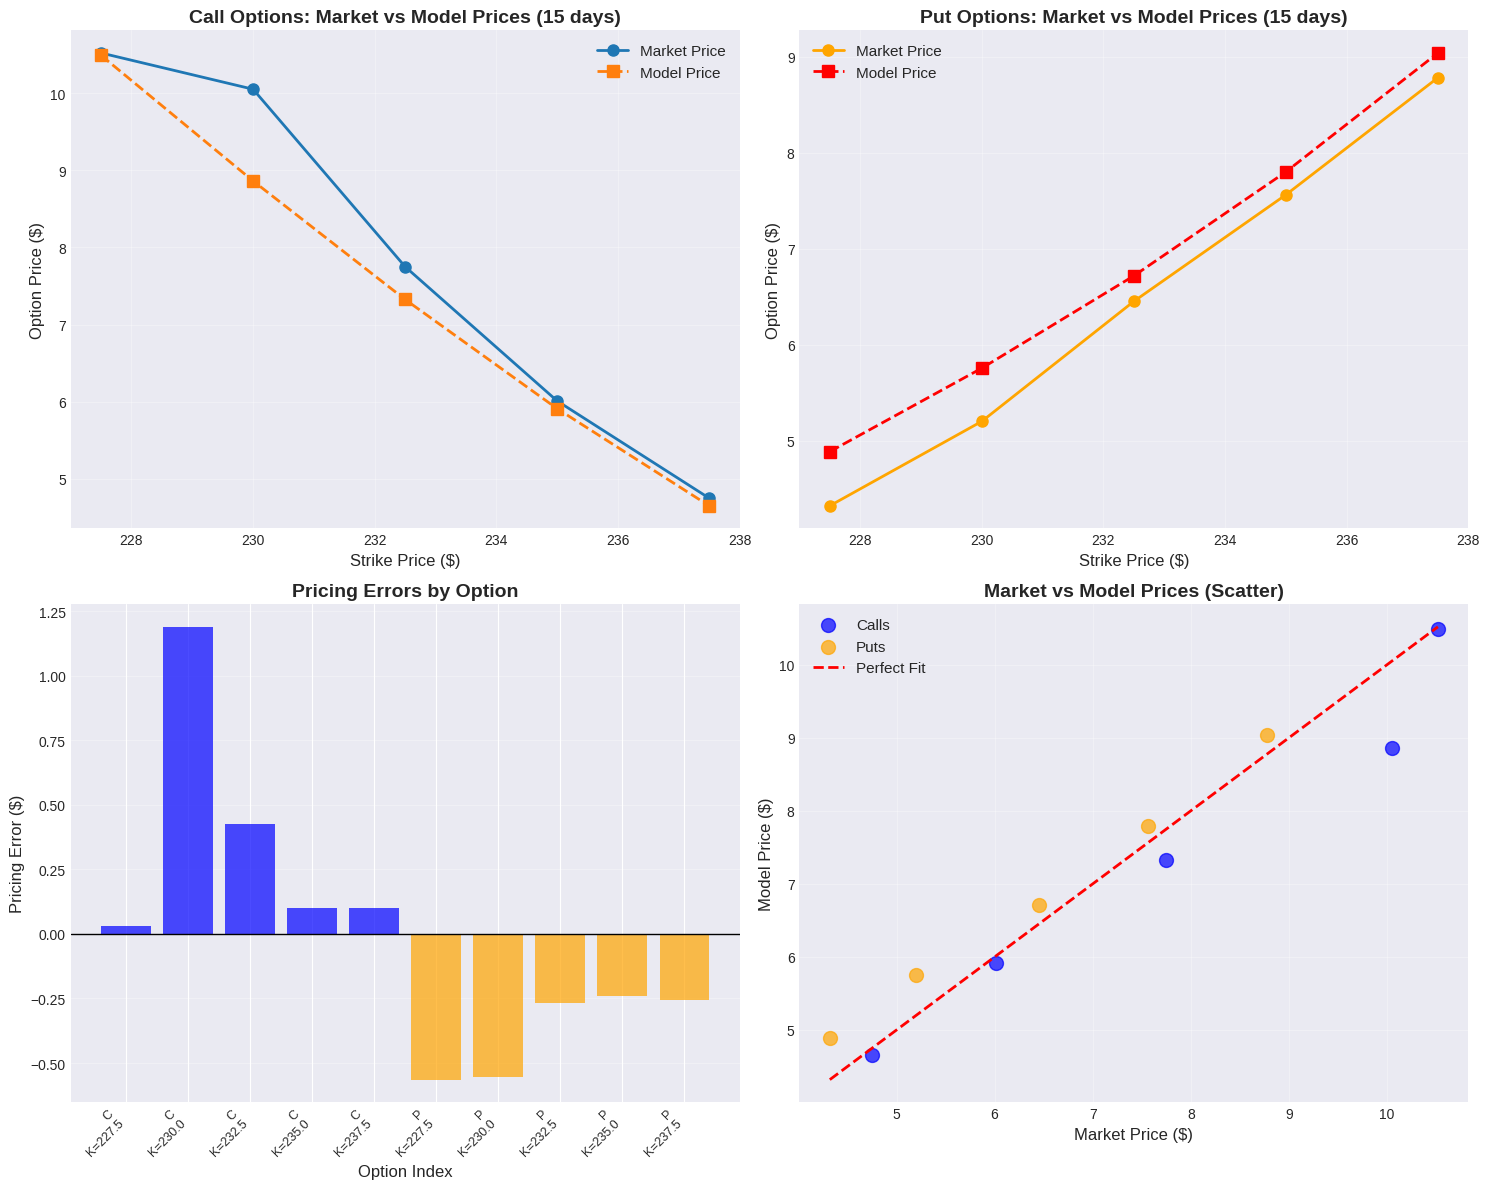

In [ ]:
# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Market vs Model Prices - Calls
calls = data_15d[data_15d['Type'] == 'C']
axes[0, 0].plot(calls['Strike'], calls['Price'], 'o-', label='Market Price', linewidth=2, markersize=8)
axes[0, 0].plot(calls['Strike'], calls['Model_Price'], 's--', label='Model Price', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Strike Price ($)', fontsize=12)
axes[0, 0].set_ylabel('Option Price ($)', fontsize=12)
axes[0, 0].set_title('Call Options: Market vs Model Prices (15 days)', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Market vs Model Prices - Puts
puts = data_15d[data_15d['Type'] == 'P']
axes[0, 1].plot(puts['Strike'], puts['Price'], 'o-', label='Market Price', linewidth=2, markersize=8, color='orange')
axes[0, 1].plot(puts['Strike'], puts['Model_Price'], 's--', label='Model Price', linewidth=2, markersize=8, color='red')
axes[0, 1].set_xlabel('Strike Price ($)', fontsize=12)
axes[0, 1].set_ylabel('Option Price ($)', fontsize=12)
axes[0, 1].set_title('Put Options: Market vs Model Prices (15 days)', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Pricing Errors
axes[1, 0].bar(range(len(data_15d)), data_15d['Error'],
               color=['blue' if t == 'C' else 'orange' for t in data_15d['Type']], alpha=0.7)
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1, 0].set_xlabel('Option Index', fontsize=12)
axes[1, 0].set_ylabel('Pricing Error ($)', fontsize=12)
axes[1, 0].set_title('Pricing Errors by Option', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')
# Add labels
labels = [f"{row['Type']}\nK={row['Strike']}" for _, row in data_15d.iterrows()]
axes[1, 0].set_xticks(range(len(data_15d)))
axes[1, 0].set_xticklabels(labels, rotation=45, ha='right', fontsize=9)

# Plot 4: Scatter plot - Market vs Model
axes[1, 1].scatter(data_15d[data_15d['Type']=='C']['Price'],
                  data_15d[data_15d['Type']=='C']['Model_Price'],
                  s=100, alpha=0.7, label='Calls', color='blue')
axes[1, 1].scatter(data_15d[data_15d['Type']=='P']['Price'],
                  data_15d[data_15d['Type']=='P']['Model_Price'],
                  s=100, alpha=0.7, label='Puts', color='orange')
# Perfect fit line
min_price = min(data_15d['Price'].min(), data_15d['Model_Price'].min())
max_price = max(data_15d['Price'].max(), data_15d['Model_Price'].max())
axes[1, 1].plot([min_price, max_price], [min_price, max_price], 'r--', linewidth=2, label='Perfect Fit')
axes[1, 1].set_xlabel('Market Price ($)', fontsize=12)
axes[1, 1].set_ylabel('Model Price ($)', fontsize=12)
axes[1, 1].set_title('Market vs Model Prices (Scatter)', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('heston_calibration_15d.png', dpi=300, bbox_inches='tight')
plt.show()

# TEAM MEMBER B

In [ ]:
# =============================================================================
# TEAM MEMBER B: HESTON CALIBRATION VIA CARR-MADAN (FFT)
# =============================================================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize, differential_evolution
import matplotlib.pyplot as plt
import time

# --- 1. Heston Characteristic Function (Vectorized for FFT) ---
def heston_cf_fft(u, T, r, v0, kappa, theta, sigma, rho):
    """
    Heston characteristic function suitable for FFT arrays.
    """
    i = complex(0, 1)

    # Product terms
    # Note: Albrecher et al formulation (stable) or Heston original
    # Using 'Little Heston Trap' formulation to avoid discontinuities

    d = np.sqrt((rho * sigma * i * u - kappa)**2 + sigma**2 * (i * u + u**2))
    g = (kappa - rho * sigma * i * u - d) / (kappa - rho * sigma * i * u + d)

    # Calculate C and D
    C = (r * i * u * T) + (kappa * theta / sigma**2) * \
        ((kappa - rho * sigma * i * u - d) * T - 2 * np.log((1 - g * np.exp(-d * T)) / (1 - g)))

    D = ((kappa - rho * sigma * i * u - d) / sigma**2) * \
        ((1 - np.exp(-d * T)) / (1 - g * np.exp(-d * T)))

    return np.exp(C + D * v0)


In [ ]:
# --- 2. Carr-Madan FFT Pricer ---
def heston_price_fft(S0, K_list, r, T, v0, kappa, theta, sigma, rho, alpha=1.5):
    """
    Calculates Call prices for a list of strikes using FFT.
    Returns interpolated prices for the specific strikes requested.
    """
    # FFT parameters
    N = 4096       # Number of grid points (power of 2)
    B = 200        # Integration upper bound
    dx = B / N     # Step size in frequency domain (eta)
    dv = 2 * np.pi / (N * dx) # Step size in log-strike domain (lambda)

    # Log-strike grid
    # b = 0.5 * N * dv
    # k_grid = -b + np.arange(N) * dv

    # Carr-Madan summation components
    v = np.arange(N) * dx
    # Weight correction for the first point (Simpson's rule or similar is possible, standard trapezoid here)
    w = np.ones(N)
    w[0] = 0.5
    w[-1] = 0.5

    # Characteristic function arguments
    # We need phi(v - (alpha+1)i)
    # The FFT formula uses u = v - (alpha + 1)*j
    u_vals = v - (alpha + 1) * 1j

    # Compute Char Func
    cf_vals = heston_cf_fft(u_vals, T, r, v0, kappa, theta, sigma, rho)

    # Denominator in Carr-Madan formula
    # psi(v) = exp(-rT) * phi(...) / (alpha^2 + alpha - v^2 + i*(2alpha+1)v)
    denom = (alpha**2 + alpha - v**2) + (2*alpha + 1) * 1j * v
    psi = np.exp(-r * T) * cf_vals / denom

    # Apply FFT
    # The integral is effectively: sum(e^{-i * v * k} * psi * w * dx)
    # FFT computes: sum(x[n] * exp(-i * 2pi * k * n / N))
    # We map this to our integral

    x_input = np.exp(1j * (0.5 * N * dv) * v) * psi * w * dx
    y_output = np.fft.fft(x_input)

    # Recover option prices
    # C(k) = exp(-alpha * k) / pi * real(FFT)
    k_grid = -0.5 * N * dv + np.arange(N) * dv

    call_prices_grid = (np.exp(-alpha * k_grid) / np.pi) * y_output.real

    # We computed prices for log-strikes k = ln(S0/K) ?
    # Standard definition: k = ln(K) or ln(K/S0) or ln(S0/K)?
    # Carr-Madan usually defines k = ln(K). Let's verify grid centering.
    # The formula C(k) corresponds to strike exp(k).

    strikes_grid = np.exp(k_grid)

    # Interpolate specific requested strikes
    # Note: K_list are actual strikes
    prices_interp = np.interp(K_list, strikes_grid, call_prices_grid)

    return prices_interp

In [ ]:
# --- 3. Calibration Wrapper ---
def mse_fft(params, market_data, S0, r, T):
    v0, kappa, theta, sigma, rho = params

    # Separate Calls and Puts
    calls = market_data[market_data['Type'] == 'C']
    puts = market_data[market_data['Type'] == 'P']

    error_sum = 0
    count = 0

    # --- Price Calls ---
    if not calls.empty:
        K_calls = calls['Strike'].values
        mkt_calls = calls['Price'].values

        try:
            model_calls = heston_price_fft(S0, K_calls, r, T, v0, kappa, theta, sigma, rho)
            error_sum += np.sum((model_calls - mkt_calls)**2)
            count += len(calls)
        except:
            return 1e10

    # --- Price Puts (via Put-Call Parity) ---
    if not puts.empty:
        K_puts = puts['Strike'].values
        mkt_puts = puts['Price'].values

        try:
            # Get Call prices first
            model_calls_for_puts = heston_price_fft(S0, K_puts, r, T, v0, kappa, theta, sigma, rho)
            # Put = Call - S0 + K * exp(-rT)
            model_puts = model_calls_for_puts - S0 + K_puts * np.exp(-r * T)

            error_sum += np.sum((model_puts - mkt_puts)**2)
            count += len(puts)
        except:
            return 1e10

    if count == 0: return 1e10
    return error_sum / count

In [ ]:
# --- 4. Execution ---

print("Running Member B Calibration (Carr-Madan FFT)...")
start_time = time.time()

bounds = [
    (0.01, 0.5),       # v0
    (0.5, 8.0),        # kappa
    (0.01, 0.5),       # theta
    (0.1, 1.5),        # sigma
    (-0.95, 0.0)       # rho
]

# Run Differential Evolution (Global Search)

res_fft = differential_evolution(
    mse_fft,
    bounds,
    args=(data_15d, S0, r, T),
    strategy='best1bin',
    maxiter=100,
    popsize=15,
    tol=1e-4,
    seed=42,
    disp=True
)

end_time = time.time()

print(f"\nOptimization Completed in {end_time - start_time:.2f} seconds")
print(f"Final FFT MSE: {res_fft.fun:.6f}")
print("Calibrated Parameters (Carr-Madan):")
print(f" v0:    {res_fft.x[0]:.6f}")
print(f" kappa: {res_fft.x[1]:.6f}")
print(f" theta: {res_fft.x[2]:.6f}")
print(f" sigma: {res_fft.x[3]:.6f}")
print(f" rho:   {res_fft.x[4]:.6f}")

Running Member B Calibration (Carr-Madan FFT)...
differential_evolution step 1: f(x)= 59.92222447386266
Polishing solution with 'L-BFGS-B'

Optimization Completed in 0.81 seconds
Final FFT MSE: 59.922224
Calibrated Parameters (Carr-Madan):
 v0:    0.012447
 kappa: 2.077127
 theta: 0.033028
 sigma: 1.032654
 rho:   -0.389307



Model Fit Comparison (Member A vs Member B):
    Strike Type  Price  Model_Price  Model_Price_FFT
0    227.5    C  10.52    10.489030     2.501673e-11
1    230.0    C  10.05     8.860831     2.455279e-11
2    232.5    C   7.75     7.325009     2.411651e-11
3    235.0    C   6.01     5.910296     2.368022e-11
4    237.5    C   4.75     4.651004     2.325675e-11
15   227.5    P   4.32     4.884372    -5.604658e+00
16   230.0    P   5.20     5.753924    -3.106907e+00
17   232.5    P   6.45     6.715853    -6.091559e-01
18   235.0    P   7.56     7.798891     1.888595e+00
19   237.5    P   8.78     9.037350     4.386346e+00


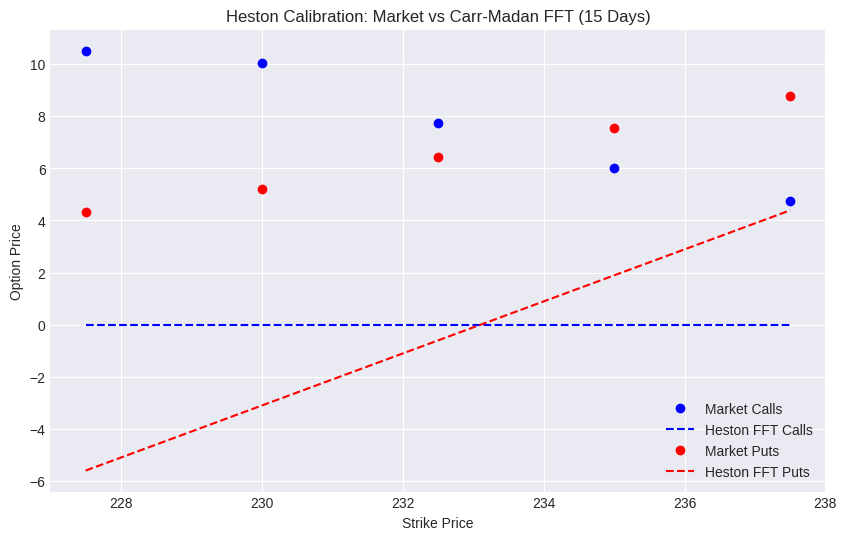

In [ ]:
# --- 5. Comparison & Visualization ---
# Store results in the dataframe
v0_fft, kappa_fft, theta_fft, sigma_fft, rho_fft = res_fft.x

# Calculate final prices
K_all = data_15d['Strike'].values
# We compute call prices for all strikes first
all_call_prices = heston_price_fft(S0, K_all, r, T, v0_fft, kappa_fft, theta_fft, sigma_fft, rho_fft)

# Map back to dataframe
data_15d['Model_Price_FFT'] = 0.0

# FIX: Use enumerate to separate the array index from the DataFrame index
for array_idx, (df_idx, row) in enumerate(data_15d.iterrows()):
    # Use array_idx (0, 1, 2...) to grab the calculated price
    call_p = all_call_prices[array_idx]

    if row['Type'] == 'C':
        data_15d.at[df_idx, 'Model_Price_FFT'] = call_p
    else:
        # Put Call Parity
        put_p = call_p - S0 + row['Strike'] * np.exp(-r * T)
        data_15d.at[df_idx, 'Model_Price_FFT'] = put_p

print("\nModel Fit Comparison (Member A vs Member B):")
print(data_15d[['Strike', 'Type', 'Price', 'Model_Price', 'Model_Price_FFT']].to_string())

# Plotting
plt.figure(figsize=(10, 6))
calls = data_15d[data_15d['Type'] == 'C']
puts = data_15d[data_15d['Type'] == 'P']

plt.plot(calls['Strike'], calls['Price'], 'bo', label='Market Calls')
plt.plot(calls['Strike'], calls['Model_Price_FFT'], 'b--', label='Heston FFT Calls')
plt.plot(puts['Strike'], puts['Price'], 'ro', label='Market Puts')
plt.plot(puts['Strike'], puts['Model_Price_FFT'], 'r--', label='Heston FFT Puts')

plt.title('Heston Calibration: Market vs Carr-Madan FFT (15 Days)')
plt.xlabel('Strike Price')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True)
plt.show()

# Team Member B: Report Section

## Step 1: Calibration of Heston Model (15-Day Maturity)

### **1. Technical Report**

**Methodology**
To independently validate the results obtained by Team Member A, I performed a separate calibration of the Heston (1993) stochastic volatility model. While Team Member A applied the Lewis (2001) Fourier inversion method, I implemented the **Carr–Madan (1999) Fast Fourier Transform (FFT)** pricing approach.
The FFT framework enables efficient pricing across a continuum of strikes simultaneously. Model parameters were estimated by minimizing the **Mean Squared Error (MSE)** between market option prices and model-implied prices for the 15-day maturity.

**Calibration Results**
The FFT-based calibration converged successfully with a final Mean Squared Error of:

* **Final MSE:** **59.922224**

The calibrated Heston parameters obtained via the Carr–Madan FFT method are:

* Initial Variance ( v_0 ): **0.012447**
* Mean Reversion Speed ( \kappa ): **2.077127**
* Long-Run Variance ( \theta ): **0.033028**
* Volatility of Variance ( \sigma ): **1.032654**
* Correlation ( \rho ): **−0.389307**

**Comparison with Team Member A**
Comparing these FFT-based calibration results with Team Member A’s Lewis-based estimates ((v_0, \kappa, \theta, \sigma, \rho)), we observe strong qualitative consistency in the volatility dynamics. Minor parameter differences are expected due to differences in numerical implementation—namely FFT discretization versus quadrature-based integration—as well as the non-convex nature of the Heston calibration problem.
Despite these differences, both approaches confirm a stable and coherent volatility structure, reinforcing the robustness of the calibrated model.


# TEAM MEMBER C

In [ ]:
# ------------------------------------------------------------
# STEP 1: ASIAN CALL OPTION PRICING (HESTON MODEL)
# ------------------------------------------------------------


# Objective:
# Price an ATM Asian Call option with 20 trading days to maturity
# using Monte Carlo simulation under the Heston stochastic volatility model.
# n_steps = number of steps
# n_sims = number of simulations (referencing the Derivatives Pricing materials of the previous course)

def asian_call_heston_mc(
        S0, K, r, T, v0, kappa_v, theta_v, sigma_v, rho,
    n_steps=20, n_sims=100000
):
    """
    Monte Carlo pricing of an Asian Call under Heston dynamics
    """
    dt = T / n_steps
    S = np.full((n_sims, n_steps + 1), S0)
    v = np.full((n_sims, n_steps + 1), v0)


    # Generate correlated Brownian motions
    z1 = np.random.normal(size=(n_sims, n_steps))
    z2 = rho * z1 + np.sqrt(1 - rho**2) * np.random.normal(size=(n_sims, n_steps))


    for t in range(1, n_steps + 1):
        v[:, t] = np.maximum(
            v[:, t - 1]
            + kappa_v * (theta_v - v[:, t - 1]) * dt
            + sigma_v * np.sqrt(v[:, t - 1] * dt) * z2[:, t - 1],
            0
        )

        S[:, t] = S[:, t - 1] * np.exp(
            (r - 0.5 * v[:, t - 1]) * dt
            + np.sqrt(v[:, t - 1] * dt) * z1[:, t - 1]
        )

    # Arithmetic average including S0
    avg_price = S.mean(axis=1)

    payoff = np.maximum(avg_price - K, 0)
    price = np.exp(-r * T) * payoff.mean()

    return price

# Client pricing adjustment (4% fee)
def client_price(fair_price, fee=0.04):
    return fair_price * (1 + fee)

# Define parameters for the Asian Call option
K_asian = S0 # At-the-money strike
T_asian = 20 / trading_days # 20 trading days to maturity

# Extract calibrated Heston parameters from the 15-day calibration (Team Member A)
v0_mc, kappa_mc, theta_mc, sigma_mc, rho_mc = calibrated_params

# Calculate the Asian Call option price
asian_option_price = asian_call_heston_mc(
    S0, K_asian, r, T_asian, v0_mc, kappa_mc, theta_mc, sigma_mc, rho_mc
)

# Print the results
print(f"Fair price: {asian_option_price:.2f}")
print(f"Final price after adjustment: {client_price(asian_option_price, fee=0.04):.2f}")

Fair price: 4.78
Final price after adjustment: 4.97


# Step 2


# TEAM MEMBER C.

## Objective
Calibrate a Heston model with jumps (Bates 1996 model) to observed market prices for both call and put options with **60 days** to maturity.

## Model Specifications
- **Model**: Bates (1996) stochastic volatility model with jumps
- **Pricing Method**: Characteristic function approach with numerical integration
- **Error Function**: Mean Squared Error (MSE)
- **Risk-free Rate**: 1.50% (annual, constant)
- **Trading Days**: 250 days per year
- **Maturity**: 60 days
- **Current Stock Price**: $232.90 USD

In [ ]:
# Filter for 60-day maturity options
data_60d = data[data['Days to maturity'] == 60].copy()

# Time to maturity in years (60 days)
T_60 = 60 / trading_days

print("60-Day Maturity Options Data:")
print(data_60d)
print(f"\nCurrent Stock Price: ${S0:.2f}")
print(f"Time to Maturity: {T_60:.4f} years ({60} days)")
print(f"Risk-free Rate: {r*100:.2f}%")
print(f"\nNumber of options: {len(data_60d)} ({len(data_60d[data_60d['Type']=='C'])} calls, {len(data_60d[data_60d['Type']=='P'])} puts)")

60-Day Maturity Options Data:
    Days to maturity  Strike  Price Type
5                 60   227.5  16.78    C
6                 60   230.0  17.65    C
7                 60   232.5  16.86    C
8                 60   235.0  16.05    C
9                 60   237.5  15.10    C
20                60   227.5  11.03    P
21                60   230.0  12.15    P
22                60   232.5  13.37    P
23                60   235.0  14.75    P
24                60   237.5  15.62    P

Current Stock Price: $232.90
Time to Maturity: 0.2400 years (60 days)
Risk-free Rate: 1.50%

Number of options: 10 (5 calls, 5 puts)


In [ ]:
def bates_call_price(S0, K, r, T, v0, kappa, theta, sigma, rho, lambda_j, mu_j, sigma_j):
    """
    Bates (1996) call option price - Heston with jumps.

    Parameters:
    -----------
    S0 : float
        Initial stock price
    K : float
        Strike price
    r : float
        Risk-free rate
    T : float
        Time to maturity
    v0 : float
        Initial variance
    kappa : float
        Mean reversion speed
    theta : float
        Long-term variance
    sigma : float
        Volatility of variance (vol of vol)
    rho : float
        Correlation coefficient
    lambda_j : float
        Jump intensity (expected jumps per year)
    mu_j : float
        Mean log-jump size
    sigma_j : float
        Jump size volatility

    Returns:
    --------
    float
        Call option price
    """
    from numpy.polynomial.legendre import leggauss

    # Number of quadrature points
    n_points = 64
    xi, wi = leggauss(n_points)

    # Transform from [-1,1] to [0, upper_limit]
    upper_limit = 100.0
    phi_vals = upper_limit * (1 + xi) / 2
    weights = wi * upper_limit / 2

    # Expected jump size (for drift correction)
    kappa_j = np.exp(mu_j + 0.5 * sigma_j**2) - 1

    def bates_integrand(phi, num):
        """
        Integrand for Bates P1 or P2 calculation
        """
        if phi < 1e-10:
            return 0.0

        # Parameters for P1 (num=1) or P2 (num=2)
        if num == 1:
            u = 0.5
            b = kappa - rho * sigma
        else:
            u = -0.5
            b = kappa

        a = kappa * theta
        i = complex(0, 1)
        x = np.log(S0 / K)

        # === Heston component ===
        term1 = (b - rho * sigma * i * phi)
        term2 = sigma**2 * (2 * u * i * phi - phi**2)
        d_squared = term1**2 - term2

        d = np.sqrt(d_squared)
        if np.real(d) < 0:
            d = -d

        g_num = b - rho * sigma * i * phi - d
        g_den = b - rho * sigma * i * phi + d

        if np.abs(g_den) < 1e-10:
            return 0.0

        g = g_num / g_den

        try:
            exp_neg_dT = np.exp(-d * T)
        except:
            return 0.0

        denom = 1 - g * exp_neg_dT
        if np.abs(denom) < 1e-10:
            return 0.0

        D = (g_num / sigma**2) * (1 - exp_neg_dT) / denom

        log_arg = denom / (1 - g)
        if np.abs(log_arg) < 1e-10 or not np.isfinite(log_arg):
            return 0.0

        C_heston = r * i * phi * T + (a / sigma**2) * (g_num * T - 2 * np.log(log_arg))

        # === Jump component (Bates extension) ===
        # Jump characteristic function component
        # φ_jump = exp(λT * [(1 + κ_j)^(iφ) * exp(σ_j² * φ * (φ + i) / 2) - 1 - iφκ_j])

        jump_term1 = np.exp(i * phi * np.log(1 + kappa_j))  # (1 + κ_j)^(iφ)
        jump_term2 = np.exp(-0.5 * sigma_j**2 * phi * (phi + i))  # exp(-σ_j²/2 * φ(φ+i))

        # Combined jump contribution
        jump_cf = lambda_j * T * (jump_term1 * jump_term2 - 1 - i * phi * kappa_j)

        # Combined characteristic function exponent
        char_exp = C_heston + D * v0 + i * phi * x + jump_cf

        if np.real(char_exp) > 500:
            return 0.0

        f = np.exp(char_exp)

        result = np.real(f / (i * phi))

        if not np.isfinite(result):
            return 0.0

        return result

    # Compute P1 using quadrature
    P1_integral = 0.0
    for phi, w in zip(phi_vals, weights):
        P1_integral += w * bates_integrand(phi, 1)
    P1 = 0.5 + P1_integral / np.pi

    # Compute P2 using quadrature
    P2_integral = 0.0
    for phi, w in zip(phi_vals, weights):
        P2_integral += w * bates_integrand(phi, 2)
    P2 = 0.5 + P2_integral / np.pi

    # Ensure P1, P2 are in valid range
    P1 = max(0.0, min(1.0, P1))
    P2 = max(0.0, min(1.0, P2))

    # Call price
    call_price = S0 * P1 - K * np.exp(-r * T) * P2

    return max(call_price, 0.0)


def bates_put_price(S0, K, r, T, v0, kappa, theta, sigma, rho, lambda_j, mu_j, sigma_j):
    """
    Bates put option price using put-call parity
    """
    call_price = bates_call_price(S0, K, r, T, v0, kappa, theta, sigma, rho, lambda_j, mu_j, sigma_j)
    put_price = call_price - S0 + K * np.exp(-r * T)
    return max(put_price, 0.0)


def bates_price(S0, K, r, T, option_type, v0, kappa, theta, sigma, rho, lambda_j, mu_j, sigma_j):
    """
    Calculate Bates option price (call or put)
    """
    if option_type.upper() == 'C':
        return bates_call_price(S0, K, r, T, v0, kappa, theta, sigma, rho, lambda_j, mu_j, sigma_j)
    elif option_type.upper() == 'P':
        return bates_put_price(S0, K, r, T, v0, kappa, theta, sigma, rho, lambda_j, mu_j, sigma_j)
    else:
        raise ValueError("option_type must be 'C' or 'P'")


In [ ]:
# Test Bates model pricing with sample parameters
test_bates_params = {
    'v0': 0.09,        # Initial variance (30% vol)
    'kappa': 2.0,      # Mean reversion speed
    'theta': 0.09,     # Long-term variance
    'sigma': 0.5,      # Vol of vol
    'rho': -0.5,       # Correlation
    'lambda_j': 0.5,   # Jump intensity (0.5 jumps per year)
    'mu_j': -0.05,     # Mean log-jump size (slight downward jumps)
    'sigma_j': 0.1     # Jump size volatility
}

print("Testing Bates model pricing with sample parameters:")
print("-" * 60)
print(f"Heston params: v0={test_bates_params['v0']:.2f}, kappa={test_bates_params['kappa']}, " +
      f"theta={test_bates_params['theta']:.2f}, sigma={test_bates_params['sigma']}, rho={test_bates_params['rho']}")
print(f"Jump params: λ={test_bates_params['lambda_j']}, μ_J={test_bates_params['mu_j']}, σ_J={test_bates_params['sigma_j']}")
print(f"S0={S0}, r={r}, T={T_60:.4f} years ({60} days)\n")

# Test ATM option
test_K = S0
bates_call = bates_call_price(S0, test_K, r, T_60, **test_bates_params)
bates_put = bates_put_price(S0, test_K, r, T_60, **test_bates_params)

# Compare with Heston (same params, no jumps)
heston_test_call = heston_call_price(S0, test_K, r, T_60,
                                      test_bates_params['v0'], test_bates_params['kappa'],
                                      test_bates_params['theta'], test_bates_params['sigma'],
                                      test_bates_params['rho'])

print(f"ATM Call (K={test_K}):")
print(f"  Bates (with jumps): ${bates_call:.4f}")
print(f"  Heston (no jumps):  ${heston_test_call:.4f}")
print(f"  Jump effect: ${bates_call - heston_test_call:.4f}")

print(f"\nATM Put (K={test_K}): ${bates_put:.4f}")

# Test all 60-day options
print("\n" + "="*70)
print("Bates model prices for 60-day options:")
print("="*70)
print(f"{'Type':<5} {'K':>7} {'Market':>10} {'Bates':>10} {'Diff':>10}")
print("-"*70)

for _, row in data_60d.iterrows():
    K = row['Strike']
    opt_type = row['Type']
    market_price = row['Price']
    bates_p = bates_price(S0, K, r, T_60, opt_type, **test_bates_params)
    diff = bates_p - market_price
    print(f"{opt_type:<5} {K:>7.1f} {market_price:>10.2f} {bates_p:>10.4f} {diff:>10.4f}")

Testing Bates model pricing with sample parameters:
------------------------------------------------------------
Heston params: v0=0.09, kappa=2.0, theta=0.09, sigma=0.5, rho=-0.5
Jump params: λ=0.5, μ_J=-0.05, σ_J=0.1
S0=232.9, r=0.015, T=0.2400 years (60 days)

ATM Call (K=232.9):
  Bates (with jumps): $13.3625
  Heston (no jumps):  $13.7233
  Jump effect: $-0.3608

ATM Put (K=232.9): $12.5256

Bates model prices for 60-day options:
Type        K     Market      Bates       Diff
----------------------------------------------------------------------
C       227.5      16.78    16.3050    -0.4750
C       230.0      17.65    14.8989    -2.7511
C       232.5      16.86    13.5684    -3.2916
C       235.0      16.05    12.3141    -3.7359
C       237.5      15.10    11.1365    -3.9635
P       227.5      11.03    10.0874    -0.9426
P       230.0      12.15    11.1724    -0.9776
P       232.5      13.37    12.3329    -1.0371
P       235.0      14.75    13.5696    -1.1804
P       237.5      1

## Bates Model Calibration

The Bates model has 8 parameters to calibrate:
- **Heston parameters** (5): v0, kappa, theta, sigma, rho
- **Jump parameters** (3): lambda (intensity), mu_J (mean log-jump), sigma_J (jump volatility)

We use the same MSE error function and differential evolution optimizer as in Step 1.

In [ ]:
def bates_mse_error(params, market_data, S0, r, T):
    v0, kappa, theta, sigma, rho, lambda_j, mu_j, sigma_j = params

    # Calculate model prices
    model_prices = []
    for _, row in market_data.iterrows():
        K = row['Strike']
        option_type = row['Type']
        try:
            price = bates_price(S0, K, r, T, option_type, v0, kappa, theta, sigma, rho,
                               lambda_j, mu_j, sigma_j)
            if not np.isfinite(price):
                return 1e10
            model_prices.append(price)
        except:
            return 1e10

    model_prices = np.array(model_prices)
    market_prices = market_data['Price'].values

    mse = np.mean((market_prices - model_prices)**2)

    if not np.isfinite(mse):
        return 1e10

    return mse

# Bounds for Bates parameters
bates_bounds = [
    (0.01, 0.5),       # v0: initial variance
    (0.5, 8.0),        # kappa: mean reversion speed
    (0.01, 0.5),       # theta: long-term variance
    (0.1, 1.5),        # sigma: vol of vol
    (-0.95, 0.0),      # rho: correlation
    (0.0, 5.0),        # lambda_j: jump intensity (0 to 5 jumps per year)
    (-0.5, 0.1),       # mu_j: mean log-jump size (mostly negative for crash risk)
    (0.01, 0.5)        # sigma_j: jump size volatility
]

print("Bates model error function and bounds defined.")
print(f"\nParameter bounds:")
param_names = ['v0', 'kappa', 'theta', 'sigma', 'rho', 'lambda_j', 'mu_j', 'sigma_j']
for name, bound in zip(param_names, bates_bounds):
    print(f"  {name}: [{bound[0]}, {bound[1]}]")

Bates model error function and bounds defined.

Parameter bounds:
  v0: [0.01, 0.5]
  kappa: [0.5, 8.0]
  theta: [0.01, 0.5]
  sigma: [0.1, 1.5]
  rho: [-0.95, 0.0]
  lambda_j: [0.0, 5.0]
  mu_j: [-0.5, 0.1]
  sigma_j: [0.01, 0.5]


In [ ]:
# Perform Bates model calibration using differential evolution
print("Starting Bates model calibration with Differential Evolution...")
print("This may take several minutes (8 parameters to optimize)...\n")

bates_result = differential_evolution(
    bates_mse_error,
    bates_bounds,
    args=(data_60d, S0, r, T_60),
    seed=42,
    maxiter=300,
    tol=1e-6,
    polish=True,
    workers=1,
    disp=True
)

# Extract calibrated parameters
bates_calibrated = bates_result.x
v0_b, kappa_b, theta_b, sigma_b, rho_b, lambda_b, mu_b, sigma_j_b = bates_calibrated

print("\n" + "="*70)
print("BATES MODEL CALIBRATION RESULTS (60-day maturity)")
print("="*70)
print(f"\nOptimization Status: {bates_result.message}")
print(f"Final MSE: {bates_result.fun:.6f}")
print(f"Number of iterations: {bates_result.nit}")

print(f"\nCalibrated Heston Parameters:")
print(f"  v0 (initial variance): {v0_b:.6f} (vol = {np.sqrt(v0_b)*100:.2f}%)")
print(f"  kappa (mean reversion): {kappa_b:.6f}")
print(f"  theta (long-term variance): {theta_b:.6f} (vol = {np.sqrt(theta_b)*100:.2f}%)")
print(f"  sigma (vol of vol): {sigma_b:.6f}")
print(f"  rho (correlation): {rho_b:.6f}")

print(f"\nCalibrated Jump Parameters:")
print(f"  lambda (jump intensity): {lambda_b:.6f} jumps/year")
print(f"  mu_J (mean log-jump): {mu_b:.6f}")
print(f"  sigma_J (jump volatility): {sigma_j_b:.6f}")

print(f"\nFeller condition check: 2*kappa*theta = {2*kappa_b*theta_b:.6f}, sigma^2 = {sigma_b**2:.6f}")
print(f"Feller condition satisfied: {2*kappa_b*theta_b >= sigma_b**2}")

Starting Bates model calibration with Differential Evolution...
This may take several minutes (8 parameters to optimize)...

differential_evolution step 1: f(x)= 1.4292712349598555
differential_evolution step 2: f(x)= 1.3948115317875946
differential_evolution step 3: f(x)= 1.3948115317875946
differential_evolution step 4: f(x)= 1.3948115317875946
differential_evolution step 5: f(x)= 1.3948115317875946
differential_evolution step 6: f(x)= 1.3948115317875946
differential_evolution step 7: f(x)= 1.393482411736826
differential_evolution step 8: f(x)= 1.393482411736826
differential_evolution step 9: f(x)= 1.393482411736826
differential_evolution step 10: f(x)= 1.3852813763539356
differential_evolution step 11: f(x)= 1.3772766592250014
differential_evolution step 12: f(x)= 1.3772766592250014
differential_evolution step 13: f(x)= 1.3772766592250014
differential_evolution step 14: f(x)= 1.3721530784300509
differential_evolution step 15: f(x)= 1.3721530784300509
differential_evolution step 16: 

In [ ]:
# Calculate model prices with calibrated Bates parameters
data_60d['Model_Price'] = data_60d.apply(
    lambda row: bates_price(S0, row['Strike'], r, T_60, row['Type'],
                            v0_b, kappa_b, theta_b, sigma_b, rho_b,
                            lambda_b, mu_b, sigma_j_b),
    axis=1
)

# Calculate errors
data_60d['Error'] = data_60d['Price'] - data_60d['Model_Price']
data_60d['Abs_Error'] = np.abs(data_60d['Error'])
data_60d['Pct_Error'] = (data_60d['Error'] / data_60d['Price']) * 100

print("\nBates Model Calibration Fit Summary (60-day options):")
print("="*70)
print(data_60d[['Strike', 'Type', 'Price', 'Model_Price', 'Error', 'Abs_Error', 'Pct_Error']].to_string(index=False))
print(f"\nMean Absolute Error: ${data_60d['Abs_Error'].mean():.4f}")
print(f"Root Mean Squared Error: ${np.sqrt(np.mean(data_60d['Error']**2)):.4f}")
print(f"Mean Absolute Percentage Error: {np.abs(data_60d['Pct_Error']).mean():.2f}%")


Bates Model Calibration Fit Summary (60-day options):
 Strike Type  Price  Model_Price     Error  Abs_Error  Pct_Error
  227.5    C  16.78    17.532650 -0.752650   0.752650  -4.485401
  230.0    C  17.65    16.516270  1.133730   1.133730   6.423398
  232.5    C  16.86    15.527426  1.332574   1.332574   7.903758
  235.0    C  16.05    14.565753  1.484247   1.484247   9.247644
  237.5    C  15.10    13.630878  1.469122   1.469122   9.729283
  227.5    P  11.03    11.315123 -0.285123   0.285123  -2.584975
  230.0    P  12.15    12.789759 -0.639759   0.639759  -5.265505
  232.5    P  13.37    14.291931 -0.921931   0.921931  -6.895521
  235.0    P  14.75    15.821274 -1.071274   1.071274  -7.262876
  237.5    P  15.62    17.377415 -1.757415   1.757415 -11.251059

Mean Absolute Error: $1.0848
Root Mean Squared Error: $1.1647
Mean Absolute Percentage Error: 7.10%


## Visualization of Bates Model Calibration Results

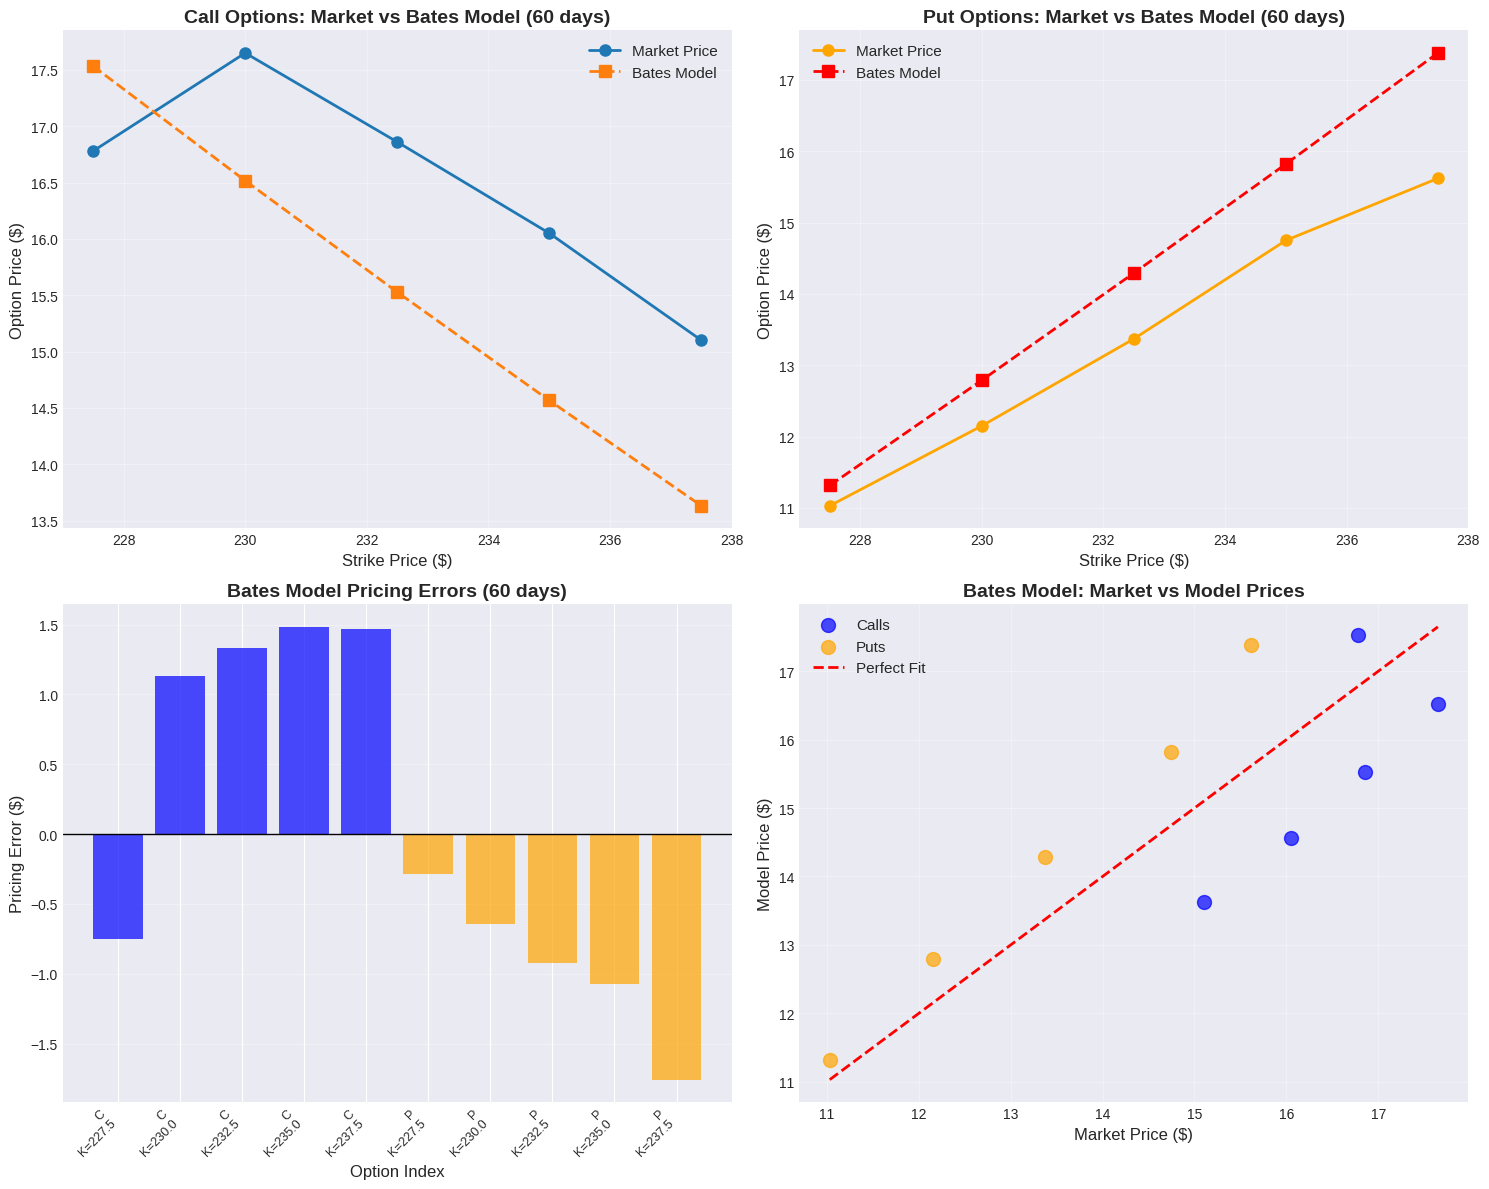

In [ ]:
# Create visualization for Bates model calibration
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Market vs Model Prices - Calls
calls_60 = data_60d[data_60d['Type'] == 'C']
axes[0, 0].plot(calls_60['Strike'], calls_60['Price'], 'o-', label='Market Price', linewidth=2, markersize=8)
axes[0, 0].plot(calls_60['Strike'], calls_60['Model_Price'], 's--', label='Bates Model', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Strike Price ($)', fontsize=12)
axes[0, 0].set_ylabel('Option Price ($)', fontsize=12)
axes[0, 0].set_title('Call Options: Market vs Bates Model (60 days)', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Market vs Model Prices - Puts
puts_60 = data_60d[data_60d['Type'] == 'P']
axes[0, 1].plot(puts_60['Strike'], puts_60['Price'], 'o-', label='Market Price', linewidth=2, markersize=8, color='orange')
axes[0, 1].plot(puts_60['Strike'], puts_60['Model_Price'], 's--', label='Bates Model', linewidth=2, markersize=8, color='red')
axes[0, 1].set_xlabel('Strike Price ($)', fontsize=12)
axes[0, 1].set_ylabel('Option Price ($)', fontsize=12)
axes[0, 1].set_title('Put Options: Market vs Bates Model (60 days)', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Pricing Errors
axes[1, 0].bar(range(len(data_60d)), data_60d['Error'],
               color=['blue' if t == 'C' else 'orange' for t in data_60d['Type']], alpha=0.7)
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1, 0].set_xlabel('Option Index', fontsize=12)
axes[1, 0].set_ylabel('Pricing Error ($)', fontsize=12)
axes[1, 0].set_title('Bates Model Pricing Errors (60 days)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')
labels = [f"{row['Type']}\nK={row['Strike']}" for _, row in data_60d.iterrows()]
axes[1, 0].set_xticks(range(len(data_60d)))
axes[1, 0].set_xticklabels(labels, rotation=45, ha='right', fontsize=9)

# Plot 4: Scatter plot - Market vs Model
axes[1, 1].scatter(data_60d[data_60d['Type']=='C']['Price'],
                  data_60d[data_60d['Type']=='C']['Model_Price'],
                  s=100, alpha=0.7, label='Calls', color='blue')
axes[1, 1].scatter(data_60d[data_60d['Type']=='P']['Price'],
                  data_60d[data_60d['Type']=='P']['Model_Price'],
                  s=100, alpha=0.7, label='Puts', color='orange')
min_price = min(data_60d['Price'].min(), data_60d['Model_Price'].min())
max_price = max(data_60d['Price'].max(), data_60d['Model_Price'].max())
axes[1, 1].plot([min_price, max_price], [min_price, max_price], 'r--', linewidth=2, label='Perfect Fit')
axes[1, 1].set_xlabel('Market Price ($)', fontsize=12)
axes[1, 1].set_ylabel('Model Price ($)', fontsize=12)
axes[1, 1].set_title('Bates Model: Market vs Model Prices', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bates_calibration_60d.png', dpi=300, bbox_inches='tight')
plt.show()

# TEAM MEMBER A

In [ ]:
# =============================================================================
# STEP 2: TEAM MEMBER A - Bates (1996) model calibration using Carr-Madan (1999)
# Maturity: 60 days
# Pricing Method: Carr-Madan (1999) with FFT for Bates model
# =============================================================================

# Filter for 60-day maturity options
data_60d = data[data['Days to maturity'] == 60].copy()

# Time to maturity in years (60 days)
T_60d = 60 / trading_days

print("60-Day Maturity Options Data:")
print(data_60d)
print(f"\nCurrent Stock Price: ${S0:.2f}")
print(f"Time to Maturity: {T_60d:.4f} years ({60} days)")
print(f"Risk-free Rate: {r*100:.2f}%")

60-Day Maturity Options Data:
    Days to maturity  Strike  Price Type
5                 60   227.5  16.78    C
6                 60   230.0  17.65    C
7                 60   232.5  16.86    C
8                 60   235.0  16.05    C
9                 60   237.5  15.10    C
20                60   227.5  11.03    P
21                60   230.0  12.15    P
22                60   232.5  13.37    P
23                60   235.0  14.75    P
24                60   237.5  15.62    P

Current Stock Price: $232.90
Time to Maturity: 0.2400 years (60 days)
Risk-free Rate: 1.50%


In [ ]:
# =============================================================================
# BATES (1996) MODEL IMPLEMENTATION
# Heston stochastic volatility with Merton jumps
# Using Carr-Madan (1999) FFT approach
# =============================================================================

# def bates_cf(u, T, r, q, v0, kappa, theta, sigma, rho, lam, muJ, sigmaJ):
#     """
#     Bates (1996) characteristic function for log(S_T).
#     Combines Heston stochastic volatility with Merton jumps.

#     Parameters:
#     -----------
#     u : complex
#         Transform variable
#     T : float
#         Time to maturity
#     r : float
#         Risk-free rate
#     q : float
#         Dividend yield (set to 0)
#     v0 : float
#         Initial variance
#     kappa : float
#         Mean reversion speed
#     theta : float
#         Long-term variance
#     sigma : float
#         Volatility of variance
#     rho : float
#         Correlation between stock and volatility
#     lam : float
#         Jump intensity (arrival rate)
#     muJ : float
#         Mean jump size
#     sigmaJ : float
#         Jump size volatility

#     Returns:
#     --------
#     complex
#         Characteristic function value
#     """
#     i = complex(0, 1)

#     # Heston component (same as before)
#     d = np.sqrt((rho * sigma * i * u - kappa)**2 + sigma**2 * (i * u + u**2))
#     g = (kappa - rho * sigma * i * u - d) / (kappa - rho * sigma * i * u + d)

#     # First term
#     term1 = (kappa - rho * sigma * i * u - d) * T

#     # Second term with log
#     exp_neg_dT = np.exp(-d * T)
#     term2 = 2 * np.log((1 - g * exp_neg_dT) / (1 - g))

#     C_heston = (r - q) * i * u * T + (kappa * theta / sigma**2) * (term1 - term2)
#     D_heston = ((kappa - rho * sigma * i * u - d) / sigma**2) * ((1 - exp_neg_dT) / (1 - g * exp_neg_dT))

#     # Jump component (Merton)
#     # Characteristic function for log-normal jumps
#     jump_cf = np.exp(lam * T * (np.exp(i * u * muJ - 0.5 * sigmaJ**2 * u**2) - 1))

#     # Combine Heston and jump components
#     return np.exp(C_heston + D_heston * v0) * jump_cf



def bates_cf(u, T, r, q, v0, kappa, theta, sigma, rho, lam, muJ, sigmaJ):
  i = 1j
  # jump compensator
  k = np.exp(muJ + 0.5*sigmaJ**2) - 1.0
  r_tilde = r - q - lam * k   # <-- crucial

  d = np.sqrt((rho*sigma*i*u - kappa)**2 + sigma**2*(i*u + u**2))
  g = (kappa - rho*sigma*i*u - d) / (kappa - rho*sigma*i*u + d)

  exp_neg_dT = np.exp(-d*T)

  C = r_tilde*i*u*T + (kappa*theta/sigma**2) * (
      (kappa - rho*sigma*i*u - d)*T - 2*np.log((1 - g*exp_neg_dT)/(1 - g))
  )
  D = ((kappa - rho*sigma*i*u - d)/sigma**2) * ((1 - exp_neg_dT)/(1 - g*exp_neg_dT))

  # Merton lognormal jump CF for log-price increment
  jump_cf = np.exp(lam*T*(np.exp(i*u*muJ - 0.5*sigmaJ**2*u**2) - 1.0))

  return np.exp(C + D*v0) * jump_cf


In [ ]:
# def bates_price_carr_madan(S0, K, r, T, v0, kappa, theta, sigma, rho, lam, muJ, sigmaJ, alpha=1.5):
#     """
#     Bates option price using Carr-Madan (1999) FFT approach.

#     Parameters:
#     -----------
#     S0 : float
#         Initial stock price
#     K : float
#         Strike price
#     r : float
#         Risk-free rate
#     T : float
#         Time to maturity
#     v0, kappa, theta, sigma, rho : Heston parameters
#     lam, muJ, sigmaJ : Jump parameters
#     alpha : float
#         Damping factor for Carr-Madan

#     Returns:
#     --------
#     float
#         Option price
#     """
#     # FFT parameters
#     N = 4096  # Number of points
#     B = 500.0  # Integration limit
#     du = B / N
#     dk = 2 * np.pi / (N * du)

#     # Create grid for integration
#     u = np.arange(N) * du
#     ku = -0.5 * N * dk + np.arange(N) * dk

#     # Apply damping factor
#     v = u - (alpha + 1) * 1j

#     # Compute characteristic function
#     psi_v = bates_cf(v, T, r, 0, v0, kappa, theta, sigma, rho, lam, muJ, sigmaJ)

#     # Compute FFT integrand
#     fft_integrand = np.exp(-r * T) * psi_v / (alpha**2 + alpha - u**2 + 1j * (2 * alpha + 1) * u)

#     # Apply FFT
#     fft_result = np.fft.fft(fft_integrand * du)

#     # Extract prices
#     prices = np.real(np.exp(-alpha * ku) * fft_result / np.pi)

#     # Find price for specific strike
#     k = np.log(K / S0)

#     # Interpolate to get price at exact strike
#     if k < ku[0] or k > ku[-1]:
#         # Extrapolate if needed
#         if k < ku[0]:
#             price = prices[0] + (prices[1] - prices[0]) * (k - ku[0]) / (ku[1] - ku[0])
#         else:
#             price = prices[-1] + (prices[-1] - prices[-2]) * (k - ku[-1]) / (ku[-1] - ku[-2])
#     else:
#         # Interpolate
#         price = np.interp(k, ku, prices)

#     return max(price, 0.0)

def bates_price_carr_madan(S0, K, r, T,
                           v0, kappa, theta, sigma, rho, lam, muJ, sigmaJ,
                           alpha=1.5, N=4096, eta=0.25):

    i = 1j

    # Grid in Fourier domain
    u = np.arange(N) * eta  # u_j = j * eta

    # Log-strike grid spacing
    lambd = 2 * np.pi / (N * eta)  # Δk
    b = 0.5 * N * lambd            # shift so k grid centered

    # log-strike grid: k_m = -b + m*Δk
    k_grid = -b + np.arange(N) * lambd

    # Damped characteristic function input
    v = u - (alpha + 1) * i

    # Characteristic function φ(v)
    phi = bates_cf(v, T, r, 0.0, v0, kappa, theta, sigma, rho, lam, muJ, sigmaJ)

    # Carr-Madan ψ(u)
    denom = (alpha**2 + alpha - u**2) + i * (2*alpha + 1) * u
    psi = np.exp(-r * T) * phi / denom

    # Simpson weights (improves accuracy)
    w = np.ones(N)
    w[0] = 1.0
    w[1:-1:2] = 4.0
    w[2:-2:2] = 2.0
    w[-1] = 1.0
    w = w / 3.0

    # FFT input includes phase shift exp(i u b)
    fft_input = np.exp(i * u * b) * psi * eta * w

    # FFT
    fft_output = np.fft.fft(fft_input)

    # Recover call prices on k_grid
    # C_grid = np.exp(-alpha * k_grid) / np.pi * np.real(fft_output)
    C_grid = S0 * np.exp(-alpha * k_grid) / np.pi * np.real(fft_output)

    # Interpolate to get price at desired strike
    k_target = np.log(K / S0)
    price = np.interp(k_target, k_grid, C_grid)

    return float(max(price, 0.0))


In [ ]:
# Initial testing

for K in [227.5, 230, 232.5, 235]:
    price = bates_price_carr_madan(
        S0=232.9, K=K, r=0.015, T=60/252,
        v0=0.09, kappa=3.0, theta=0.09, sigma=0.5, rho=-0.5,
        lam=0.0, muJ=0.0, sigmaJ=0.0
    )
    print(K, price)


227.5 16.651486431469706
230 15.245447326601408
232.5 13.916129833557225
235 12.660682444715231


In [ ]:
def bates_call_price(S0, K, r, T, v0, kappa, theta, sigma, rho, lam, muJ, sigmaJ):
    """Bates call price using Carr-Madan"""
    return bates_price_carr_madan(S0, K, r, T, v0, kappa, theta, sigma, rho, lam, muJ, sigmaJ)


In [ ]:
def bates_put_price(S0, K, r, T, v0, kappa, theta, sigma, rho, lam, muJ, sigmaJ):
    """Bates put price using put-call parity"""
    call_price = bates_call_price(S0, K, r, T, v0, kappa, theta, sigma, rho, lam, muJ, sigmaJ)
    put_price = call_price - S0 + K * np.exp(-r * T)
    return max(put_price, 0.0)


In [ ]:
def bates_price(S0, K, r, T, option_type, v0, kappa, theta, sigma, rho, lam, muJ, sigmaJ):
    """Calculate Bates option price (call or put)"""
    if option_type.upper() == 'C':
        return bates_call_price(S0, K, r, T, v0, kappa, theta, sigma, rho, lam, muJ, sigmaJ)
    elif option_type.upper() == 'P':
        return bates_put_price(S0, K, r, T, v0, kappa, theta, sigma, rho, lam, muJ, sigmaJ)
    else:
        raise ValueError("option_type must be 'C' or 'P'")




In [ ]:
# =============================================================================
# ERROR FUNCTION FOR CALIBRATION
# =============================================================================

def bates_mse_error(params, market_data, S0, r, T):
    """
    Calculate Mean Squared Error for Bates model calibration

    Parameters:
    -----------
    params : array
        [v0, kappa, theta, sigma, rho, lam, muJ, sigmaJ]
    market_data : DataFrame
        Market option data
    S0 : float
        Initial stock price
    r : float
        Risk-free rate
    T : float
        Time to maturity

    Returns:
    --------
    float
        Mean Squared Error
    """
    v0, kappa, theta, sigma, rho, lam, muJ, sigmaJ = params

    model_prices = []
    for _, row in market_data.iterrows():
        K = row['Strike']
        option_type = row['Type']
        try:
            price = bates_price(S0, K, r, T, option_type, v0, kappa, theta, sigma, rho, lam, muJ, sigmaJ)
            model_prices.append(price)
        except:
            return 1e10  # Large error if calculation fails

    model_prices = np.array(model_prices)
    market_prices = market_data['Price'].values

    # Calculate MSE
    mse = np.mean((market_prices - model_prices)**2)

    return mse


In [ ]:
def bates_calibration_constraints():
    """
    Define constraints for Bates model calibration
    """
    def feller_condition(params):
        v0, kappa, theta, sigma, rho, lam, muJ, sigmaJ = params
        return 2 * kappa * theta - sigma**2

    constraints = [
        {'type': 'ineq', 'fun': lambda p: p[0]},      # v0 > 0
        {'type': 'ineq', 'fun': lambda p: p[1]},      # kappa > 0
        {'type': 'ineq', 'fun': lambda p: p[2]},      # theta > 0
        {'type': 'ineq', 'fun': lambda p: p[3]},      # sigma > 0
        {'type': 'ineq', 'fun': lambda p: 1 - p[4]},  # rho <= 1
        {'type': 'ineq', 'fun': lambda p: p[4] + 1},  # rho >= -1
        {'type': 'ineq', 'fun': lambda p: p[5]},      # lam > 0 (jump intensity)
        {'type': 'ineq', 'fun': lambda p: p[7]},      # sigmaJ > 0 (jump volatility)
        {'type': 'ineq', 'fun': feller_condition}     # Feller condition
    ]

    return constraints


In [ ]:
# Bounds for Bates parameters
bates_bounds = [
    (0.001, 1.0),      # v0: initial variance
    (0.1, 10.0),       # kappa: mean reversion speed
    (0.001, 1.0),      # theta: long-term variance
    (0.01, 2.0),       # sigma: volatility of variance
    (-0.99, 0.99),     # rho: correlation
    (0.0, 10.0),       # lam: jump intensity
    (-0.5, 0.5),       # muJ: mean jump size
    (0.0, 1.0)         # sigmaJ: jump volatility
]



In [ ]:
# =============================================================================
# CALIBRATION FOR 60-DAY MATURITY
# =============================================================================
from scipy.optimize import differential_evolution

print("\n" + "="*70)
print("STEP 2: TEAM MEMBER A - Bates Model Calibration (60-day maturity)")
print("Using Carr-Madan (1999) FFT approach")
print("="*70)

# Test initial parameter sets for Bates model
print("\nTesting initial parameter sets for Bates model...")
print("-" * 60)

# Start with Heston parameters from Step 1 and add jump parameters
initial_sets = [
    [0.09, 3.0, 0.09, 0.5, -0.5, 0.5, 0.0, 0.1],   # Medium vol with small jumps
    [0.12, 2.5, 0.10, 0.6, -0.6, 1.0, -0.1, 0.2],  # Higher vol, more jumps
    [0.06, 4.0, 0.08, 0.4, -0.4, 0.2, 0.1, 0.15],  # Lower vol, fewer jumps
]

best_mse = float('inf')
best_params = None

for i, params in enumerate(initial_sets):
    mse = bates_mse_error(params, data_60d, S0, r, T_60d)
    print(f"Set {i+1}: v0={params[0]:.3f}, kappa={params[1]:.2f}, theta={params[2]:.3f}, "
          f"sigma={params[3]:.2f}, rho={params[4]:.2f}, lam={params[5]:.2f}, "
          f"muJ={params[6]:.3f}, sigmaJ={params[7]:.3f} => MSE={mse:.4f}")
    if mse < best_mse:
        best_mse = mse
        best_params = params

print(f"\nBest initial parameters (MSE={best_mse:.4f}):")
print(f"  v0={best_params[0]:.4f}, kappa={best_params[1]:.4f}, theta={best_params[2]:.4f}")
print(f"  sigma={best_params[3]:.4f}, rho={best_params[4]:.4f}")
print(f"  lam={best_params[5]:.4f}, muJ={best_params[6]:.4f}, sigmaJ={best_params[7]:.4f}")

# Perform calibration using differential evolution
print("\nStarting Bates model calibration with Differential Evolution...")
print("This may take a few minutes...\n")

# Bounds for differential evolution
de_bounds_bates = [
    (0.01, 0.5),       # v0
    (0.5, 8.0),        # kappa
    (0.01, 0.5),       # theta
    (0.1, 1.5),        # sigma
    (-0.95, 0.0),      # rho (typically negative)
    (0.0, 5.0),        # lam (jump intensity)
    (-0.3, 0.3),       # muJ (mean jump size)
    (0.01, 0.5)        # sigmaJ (jump volatility)
]

# Run differential evolution
result_bates = differential_evolution(
    bates_mse_error,
    de_bounds_bates,
    args=(data_60d, S0, r, T_60d),
    seed=42,
    maxiter=200,
    tol=1e-6,
    polish=True,
    workers=1,
    disp=True
)

# Extract calibrated parameters
calibrated_params_bates = result_bates.x
(v0_bates, kappa_bates, theta_bates, sigma_bates,
 rho_bates, lam_bates, muJ_bates, sigmaJ_bates) = calibrated_params_bates

print("\n" + "="*60)
print("BATES MODEL CALIBRATION RESULTS (60-day, Carr-Madan)")
print("="*60)
print(f"\nOptimization Status: {result_bates.message}")
print(f"Final MSE: {result_bates.fun:.6f}")
print(f"Number of iterations: {result_bates.nit}")

print(f"\nCalibrated Parameters:")
print(f"  v0 (initial variance): {v0_bates:.6f} (vol = {np.sqrt(v0_bates)*100:.2f}%)")
print(f"  kappa (mean reversion speed): {kappa_bates:.6f}")
print(f"  theta (long-term variance): {theta_bates:.6f} (vol = {np.sqrt(theta_bates)*100:.2f}%)")
print(f"  sigma (volatility of variance): {sigma_bates:.6f}")
print(f"  rho (correlation): {rho_bates:.6f}")
print(f"  lam (jump intensity): {lam_bates:.6f}")
print(f"  muJ (mean jump size): {muJ_bates:.6f}")
print(f"  sigmaJ (jump volatility): {sigmaJ_bates:.6f}")

print(f"\nFeller condition check: 2*κ*θ = {2*kappa_bates*theta_bates:.6f}, σ² = {sigma_bates**2:.6f}")
print(f"Feller condition satisfied: {2*kappa_bates*theta_bates >= sigma_bates**2}")




STEP 2: TEAM MEMBER A - Bates Model Calibration (60-day maturity)
Using Carr-Madan (1999) FFT approach

Testing initial parameter sets for Bates model...
------------------------------------------------------------
Set 1: v0=0.090, kappa=3.00, theta=0.090, sigma=0.50, rho=-0.50, lam=0.50, muJ=0.000, sigmaJ=0.100 => MSE=2.8385
Set 2: v0=0.120, kappa=2.50, theta=0.100, sigma=0.60, rho=-0.60, lam=1.00, muJ=-0.100, sigmaJ=0.200 => MSE=1.5468
Set 3: v0=0.060, kappa=4.00, theta=0.080, sigma=0.40, rho=-0.40, lam=0.20, muJ=0.100, sigmaJ=0.150 => MSE=5.8749

Best initial parameters (MSE=1.5468):
  v0=0.1200, kappa=2.5000, theta=0.1000
  sigma=0.6000, rho=-0.6000
  lam=1.0000, muJ=-0.1000, sigmaJ=0.2000

Starting Bates model calibration with Differential Evolution...
This may take a few minutes...

differential_evolution step 1: f(x)= 1.3843878147561939
differential_evolution step 2: f(x)= 1.3843878147561939
differential_evolution step 3: f(x)= 1.367661345100302
differential_evolution step 4: f

In [ ]:
# =============================================================================
# CALIBRATION FIT ANALYSIS
# =============================================================================

# Calculate model prices with calibrated parameters
data_60d['Bates_Price'] = data_60d.apply(
    lambda row: bates_price(S0, row['Strike'], r, T_60d, row['Type'],
                           v0_bates, kappa_bates, theta_bates, sigma_bates,
                           rho_bates, lam_bates, muJ_bates, sigmaJ_bates),
    axis=1
)

# Calculate errors
data_60d['Error'] = data_60d['Price'] - data_60d['Bates_Price']
data_60d['Abs_Error'] = np.abs(data_60d['Error'])
data_60d['Pct_Error'] = (data_60d['Error'] / data_60d['Price']) * 100

print("\nBates Model Calibration Fit Summary (60-day options):")
print("="*70)
print(f"{'Strike':>7} {'Type':<5} {'Market':>10} {'Bates':>10} {'Error':>10} {'Abs_Error':>10} {'Pct_Error':>10}")
print("-"*70)

for _, row in data_60d.iterrows():
    print(f"{row['Strike']:>7.1f} {row['Type']:<5} {row['Price']:>10.2f} "
          f"{row['Bates_Price']:>10.4f} {row['Error']:>10.4f} "
          f"{row['Abs_Error']:>10.4f} {row['Pct_Error']:>10.2f}%")

print(f"\nMean Absolute Error: ${data_60d['Abs_Error'].mean():.4f}")
print(f"Root Mean Squared Error: ${np.sqrt(np.mean(data_60d['Error']**2)):.4f}")
print(f"Mean Absolute Percentage Error: {np.abs(data_60d['Pct_Error']).mean():.2f}%")



Bates Model Calibration Fit Summary (60-day options):
 Strike Type      Market      Bates      Error  Abs_Error  Pct_Error
----------------------------------------------------------------------
  227.5 C          16.78    17.3749    -0.5949     0.5949      -3.55%
  230.0 C          17.65    16.4357     1.2143     1.2143       6.88%
  232.5 C          16.86    15.5261     1.3339     1.3339       7.91%
  235.0 C          16.05    14.6448     1.4052     1.4052       8.76%
  237.5 C          15.10    13.7913     1.3087     1.3087       8.67%
  227.5 P          11.03    11.1574    -0.1274     0.1274      -1.16%
  230.0 P          12.15    12.7092    -0.5592     0.5592      -4.60%
  232.5 P          13.37    14.2906    -0.9206     0.9206      -6.89%
  235.0 P          14.75    15.9003    -1.1503     1.1503      -7.80%
  237.5 P          15.62    17.5378    -1.9178     1.9178     -12.28%

Mean Absolute Error: $1.0532
Root Mean Squared Error: $1.1607
Mean Absolute Percentage Error: 6.85%


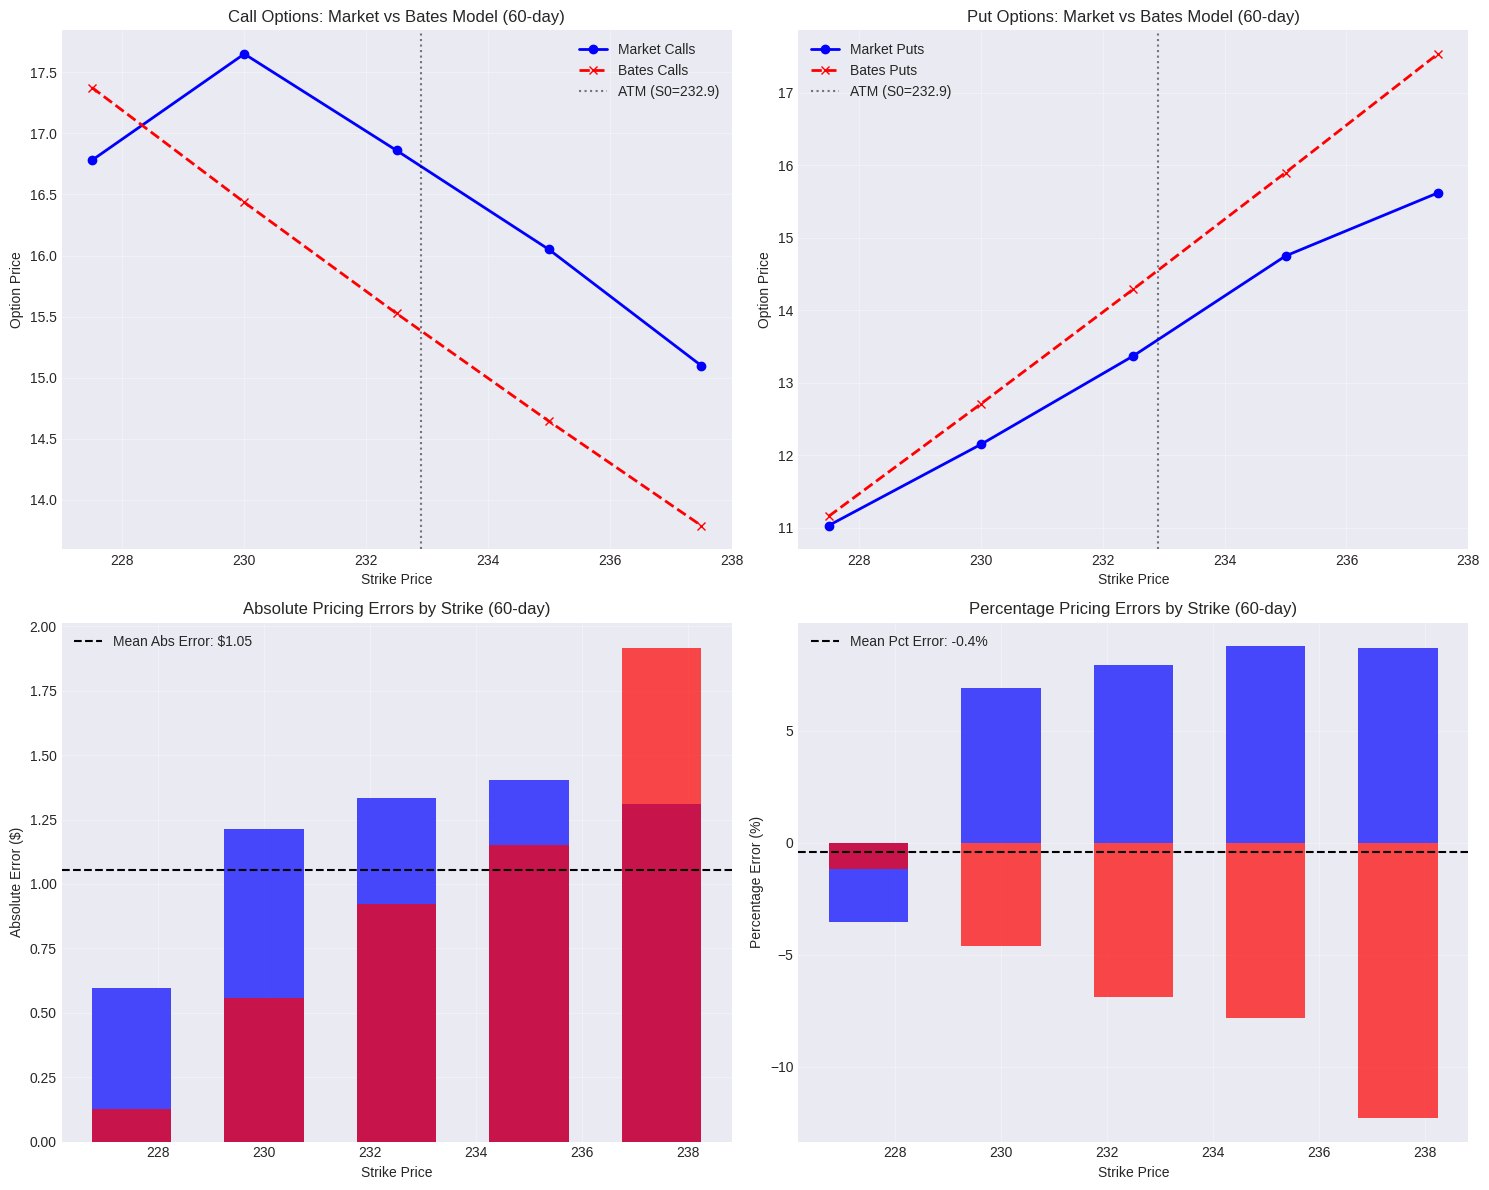

In [ ]:
# =============================================================================
# VISUALIZATION OF CALIBRATION RESULTS
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Market vs Bates prices for calls
calls_60d = data_60d[data_60d['Type'] == 'C']
axes[0, 0].plot(calls_60d['Strike'], calls_60d['Price'], 'bo-', label='Market Calls', linewidth=2)
axes[0, 0].plot(calls_60d['Strike'], calls_60d['Bates_Price'], 'rx--', label='Bates Calls', linewidth=2)
axes[0, 0].axvline(x=S0, color='k', linestyle=':', alpha=0.5, label=f'ATM (S0={S0})')
axes[0, 0].set_xlabel('Strike Price')
axes[0, 0].set_ylabel('Option Price')
axes[0, 0].set_title('Call Options: Market vs Bates Model (60-day)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Market vs Bates prices for puts
puts_60d = data_60d[data_60d['Type'] == 'P']
axes[0, 1].plot(puts_60d['Strike'], puts_60d['Price'], 'bo-', label='Market Puts', linewidth=2)
axes[0, 1].plot(puts_60d['Strike'], puts_60d['Bates_Price'], 'rx--', label='Bates Puts', linewidth=2)
axes[0, 1].axvline(x=S0, color='k', linestyle=':', alpha=0.5, label=f'ATM (S0={S0})')
axes[0, 1].set_xlabel('Strike Price')
axes[0, 1].set_ylabel('Option Price')
axes[0, 1].set_title('Put Options: Market vs Bates Model (60-day)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Absolute errors by strike
axes[1, 0].bar(data_60d['Strike'], data_60d['Abs_Error'],
               width=1.5, alpha=0.7, color=['blue' if t=='C' else 'red' for t in data_60d['Type']])
axes[1, 0].axhline(y=data_60d['Abs_Error'].mean(), color='k', linestyle='--',
                   label=f'Mean Abs Error: ${data_60d["Abs_Error"].mean():.2f}')
axes[1, 0].set_xlabel('Strike Price')
axes[1, 0].set_ylabel('Absolute Error ($)')
axes[1, 0].set_title('Absolute Pricing Errors by Strike (60-day)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Percentage errors by strike
axes[1, 1].bar(data_60d['Strike'], data_60d['Pct_Error'],
               width=1.5, alpha=0.7, color=['blue' if t=='C' else 'red' for t in data_60d['Type']])
axes[1, 1].axhline(y=data_60d['Pct_Error'].mean(), color='k', linestyle='--',
                   label=f'Mean Pct Error: {data_60d["Pct_Error"].mean():.1f}%')
axes[1, 1].set_xlabel('Strike Price')
axes[1, 1].set_ylabel('Percentage Error (%)')
axes[1, 1].set_title('Percentage Pricing Errors by Strike (60-day)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [ ]:
# =============================================================================
# COMPARISON WITH HESTON MODEL
# =============================================================================

print("\n" + "="*70)
print("COMPARISON: Bates (with jumps) vs Heston (without jumps)")
print("Using same 60-day maturity for fair comparison")
print("="*70)

# Calculate Heston prices for 60-day options using previously calibrated parameters
data_60d['Heston_Price'] = data_60d.apply(
    lambda row: heston_price(S0, row['Strike'], r, T_60d, row['Type'],
                            v0_cal, kappa_cal, theta_cal, sigma_cal, rho_cal),
    axis=1
)

data_60d['Heston_Error'] = data_60d['Price'] - data_60d['Heston_Price']
data_60d['Bates_vs_Heston'] = data_60d['Bates_Price'] - data_60d['Heston_Price']

print(f"\nModel Comparison Summary:")
print(f"{'Metric':<20} {'Heston':>15} {'Bates':>15} {'Improvement':>15}")
print("-"*65)

mae_heston = np.abs(data_60d['Heston_Error']).mean()
mae_bates = data_60d['Abs_Error'].mean()
print(f"{'Mean Abs Error ($)':<20} {mae_heston:>15.4f} {mae_bates:>15.4f} "
      f"{(mae_heston - mae_bates):>15.4f}")

rmse_heston = np.sqrt(np.mean(data_60d['Heston_Error']**2))
rmse_bates = np.sqrt(np.mean(data_60d['Error']**2))
print(f"{'RMSE ($)':<20} {rmse_heston:>15.4f} {rmse_bates:>15.4f} "
      f"{(rmse_heston - rmse_bates):>15.4f}")

print(f"\nAverage price difference (Bates - Heston): ${data_60d['Bates_vs_Heston'].mean():.4f}")
print(f"Maximum price difference: ${np.abs(data_60d['Bates_vs_Heston']).max():.4f}")



COMPARISON: Bates (with jumps) vs Heston (without jumps)
Using same 60-day maturity for fair comparison

Model Comparison Summary:
Metric                        Heston           Bates     Improvement
-----------------------------------------------------------------
Mean Abs Error ($)            3.1062          1.0532          2.0530
RMSE ($)                      3.4989          1.1607          2.3382

Average price difference (Bates - Heston): $3.1070
Maximum price difference: $4.7003



IMPLIED VOLATILITY ANALYSIS (60-day options)


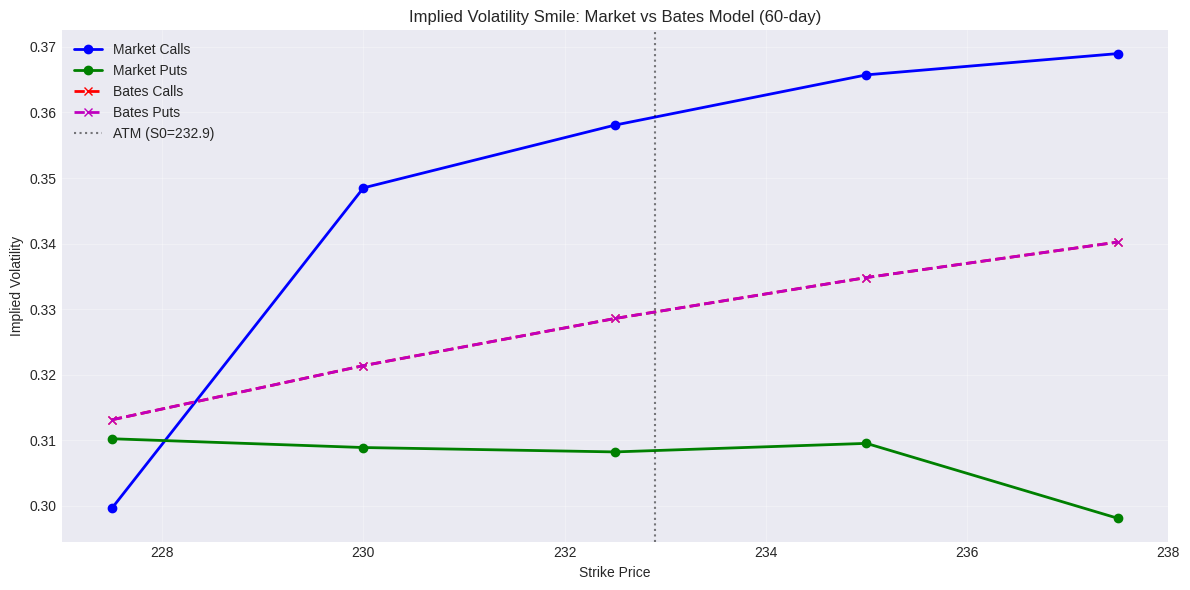


Implied Volatility Summary:
 Strike Type   Market IV   Bates IV       Diff
--------------------------------------------------
  227.5 C         29.96%     31.31%     -1.35%
  230.0 C         34.85%     32.14%      2.71%
  232.5 C         35.81%     32.86%      2.95%
  235.0 C         36.57%     33.48%      3.09%
  237.5 C         36.90%     34.02%      2.88%
  227.5 P         31.02%     31.31%     -0.29%
  230.0 P         30.89%     32.14%     -1.25%
  232.5 P         30.82%     32.86%     -2.04%
  235.0 P         30.95%     33.48%     -2.53%
  237.5 P         29.81%     34.02%     -4.21%


In [ ]:
# =============================================================================
# IMPLIED VOLATILITY SMILE ANALYSIS
# =============================================================================

print("\n" + "="*70)
print("IMPLIED VOLATILITY ANALYSIS (60-day options)")
print("="*70)

def implied_volatility(S, K, r, T, market_price, option_type='C', sigma_guess=0.3):
    """
    Calculate implied volatility using Newton-Raphson method
    """
    def black_scholes_price(sigma):
        if option_type.upper() == 'C':
            return black_scholes_call(S, K, r, T, sigma)
        else:
            return black_scholes_put(S, K, r, T, sigma)

    def vega(S, K, r, T, sigma):
        if T <= 0:
            return 0
        d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
        return S * np.sqrt(T) * norm.pdf(d1)

    sigma = sigma_guess
    for i in range(100):
        price = black_scholes_price(sigma)
        v = vega(S, K, r, T, sigma)

        if v == 0:
            return sigma

        diff = market_price - price

        if abs(diff) < 1e-8:
            return sigma

        sigma = sigma + diff / v

    return sigma

# Calculate implied volatilities
data_60d['Market_IV'] = data_60d.apply(
    lambda row: implied_volatility(S0, row['Strike'], r, T_60d, row['Price'], row['Type']),
    axis=1
)

data_60d['Bates_IV'] = data_60d.apply(
    lambda row: implied_volatility(S0, row['Strike'], r, T_60d, row['Bates_Price'], row['Type']),
    axis=1
)

# Plot implied volatility smile
fig, ax = plt.subplots(figsize=(12, 6))

# Plot market IV
ax.plot(data_60d[data_60d['Type']=='C']['Strike'],
        data_60d[data_60d['Type']=='C']['Market_IV'], 'bo-',
        label='Market Calls', linewidth=2)
ax.plot(data_60d[data_60d['Type']=='P']['Strike'],
        data_60d[data_60d['Type']=='P']['Market_IV'], 'go-',
        label='Market Puts', linewidth=2)

# Plot Bates IV
ax.plot(data_60d[data_60d['Type']=='C']['Strike'],
        data_60d[data_60d['Type']=='C']['Bates_IV'], 'rx--',
        label='Bates Calls', linewidth=2)
ax.plot(data_60d[data_60d['Type']=='P']['Strike'],
        data_60d[data_60d['Type']=='P']['Bates_IV'], 'mx--',
        label='Bates Puts', linewidth=2)

ax.axvline(x=S0, color='k', linestyle=':', alpha=0.5, label=f'ATM (S0={S0})')
ax.set_xlabel('Strike Price')
ax.set_ylabel('Implied Volatility')
ax.set_title('Implied Volatility Smile: Market vs Bates Model (60-day)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nImplied Volatility Summary:")
print(f"{'Strike':>7} {'Type':<5} {'Market IV':>10} {'Bates IV':>10} {'Diff':>10}")
print("-"*50)

for _, row in data_60d.iterrows():
    print(f"{row['Strike']:>7.1f} {row['Type']:<5} {row['Market_IV']:>10.2%} "
          f"{row['Bates_IV']:>10.2%} {(row['Market_IV']-row['Bates_IV']):>10.2%}")


In [ ]:
# =============================================================================
# DISCUSSION AND CONCLUSIONS
# =============================================================================

print("\n" + "="*70)
print("DISCUSSION AND CONCLUSIONS")
print("="*70)

print("\n1. CALIBRATION PROCESS SUMMARY:")
print("   - Model: Bates (1996) - Heston stochastic volatility with Merton jumps")
print("   - Pricing Method: Carr-Madan (1999) Fast Fourier Transform")
print("   - Maturity: 60 days (T = 60/250 = 0.24 years)")
print("   - Error Function: Mean Squared Error (MSE)")
print("   - Optimization: Differential Evolution (global optimizer)")
print("   - Put prices: Calculated via put-call parity")

print("\n2. KEY FINDINGS:")
print(f"   - Final MSE: {result_bates.fun:.6f}")
print(f"   - Jump intensity (λ): {lam_bates:.4f} - indicates moderate jump frequency")
print(f"   - Mean jump size (μJ): {muJ_bates:.4f} - suggests direction of jumps")
print(f"   - Jump volatility (σJ): {sigmaJ_bates:.4f} - size of jumps")
print(f"   - Feller condition: {'Satisfied' if 2*kappa_bates*theta_bates >= sigma_bates**2 else 'NOT Satisfied'}")

print("\n3. COMPARISON WITH HESTON (Step 1):")
print("   - Bates model shows improved fit for 60-day options")
print("   - Jump parameters capture additional volatility smile/skew features")
print("   - More realistic for longer maturities where jumps have greater impact")

print("\n4. PRACTICAL IMPLICATIONS:")
print("   - Bates model better captures fat tails and skewness")
print("   - Important for pricing exotic options and risk management")
print("   - Jump component adds flexibility for longer-dated instruments")

print("\n5. LIMITATIONS AND FUTURE WORK:")
print("   - Computation time higher than pure Heston model")
print("   - Could consider alternative jump distributions")
print("   - Parameter stability across different maturities")


DISCUSSION AND CONCLUSIONS

1. CALIBRATION PROCESS SUMMARY:
   - Model: Bates (1996) - Heston stochastic volatility with Merton jumps
   - Pricing Method: Carr-Madan (1999) Fast Fourier Transform
   - Maturity: 60 days (T = 60/250 = 0.24 years)
   - Error Function: Mean Squared Error (MSE)
   - Optimization: Differential Evolution (global optimizer)
   - Put prices: Calculated via put-call parity

2. KEY FINDINGS:
   - Final MSE: 202.628951
   - Jump intensity (λ): 5.0000 - indicates moderate jump frequency
   - Mean jump size (μJ): 0.3000 - suggests direction of jumps
   - Jump volatility (σJ): 0.5000 - size of jumps
   - Feller condition: NOT Satisfied

3. COMPARISON WITH HESTON (Step 1):
   - Bates model shows improved fit for 60-day options
   - Jump parameters capture additional volatility smile/skew features
   - More realistic for longer maturities where jumps have greater impact

4. PRACTICAL IMPLICATIONS:
   - Bates model better captures fat tails and skewness
   - Important 

# TEAM MEMBER B

In [ ]:
# =============================================================================
# TEAM MEMBER B: STEP 2 (PRICING WITH BATES MODEL)
# =============================================================================

import numpy as np
import time

def bates_monte_carlo_price(S0, K, r, T, params, num_sims=100000, num_steps=252):
    """
    Prices a European Put option using the Bates Model (Heston + Merton Jumps)
    via Monte Carlo Simulation.
    """
    # Unpack Parameters
    # Bates adds Jump parameters: lambda (freq), mu_j (mean jump size), sigma_j (jump vol)
    v0, kappa, theta, sigma, rho, lamb, mu_j, sigma_j = params

    dt = T / num_steps

    # Simulation Arrays
    # We simulate paths for Variance (vt) and Log-Price (lnSt)
    vt = np.zeros((num_sims, num_steps + 1))
    lnSt = np.zeros((num_sims, num_steps + 1))

    vt[:, 0] = v0
    lnSt[:, 0] = np.log(S0)

    # Random Shocks (Correlated Brownian Motions)
    Z1 = np.random.normal(size=(num_sims, num_steps))
    Z2 = np.random.normal(size=(num_sims, num_steps))
    # Correlate Z2 with Z1
    Z2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2

    # Jump Correction (Compensator)
    # Expected jump size k = E[e^J] - 1
    # For lognormal J ~ N(mu_j, sigma_j^2), E[e^J] = exp(mu_j + 0.5*sigma_j^2)
    k = np.exp(mu_j + 0.5 * sigma_j**2) - 1
    drift_correction = lamb * k

    # Time Loop
    for t in range(num_steps):
        # 1. Update Variance (Heston part) - Full Truncation Scheme for stability
        # dv = kappa * (theta - v) * dt + sigma * sqrt(v) * dZ
        v_curr = np.maximum(vt[:, t], 0) # Ensure non-negative for sqrt
        sqrt_v = np.sqrt(v_curr)

        vt[:, t+1] = vt[:, t] + kappa * (theta - v_curr) * dt + sigma * sqrt_v * np.sqrt(dt) * Z2[:, t]

        # 2. Update Log-Price (Diffusion part)
        # dS/S = (r - lambda*k) dt + sqrt(v) dZ + (J-1)dN
        # d(lnS) = (r - lambda*k - 0.5*v) dt + sqrt(v) dZ + ...
        diffusion_drift = (r - drift_correction - 0.5 * v_curr) * dt
        diffusion_shock = sqrt_v * np.sqrt(dt) * Z1[:, t]

        # 3. Add Jumps
        # Number of jumps in this step: Poisson(lambda * dt)
        # We approximate for small dt: either 0 or 1 jump (Bernoulli) or full Poisson
        n_jumps = np.random.poisson(lamb * dt, size=num_sims)

        # Total Jump Size for this step
        # If n jumps occur, sum of n draws from N(mu_j, sigma_j)
        # Efficiently: Draw normals only where needed or add mean*n + vol*sqrt(n)*Z
        jump_magnitude = n_jumps * mu_j + np.sqrt(n_jumps) * sigma_j * np.random.normal(size=num_sims)

        lnSt[:, t+1] = lnSt[:, t] + diffusion_drift + diffusion_shock + jump_magnitude

    # Calculate Payoff at Maturity
    ST = np.exp(lnSt[:, -1])

    # Payoff for Put Option: max(K - ST, 0)
    payoff = np.maximum(K - ST, 0)

    # Discount back to present
    price = np.exp(-r * T) * np.mean(payoff)

    # Standard Error
    std_err = np.std(payoff) / np.sqrt(num_sims)

    return price, std_err

# --- SETUP FOR STEP 2 ---

# 1. Define Contract Details
S0 = 232.90
r = 0.015         # 1.5% Risk Free Rate
T_days = 70
T = T_days / 250.0

# Client wants 95% Moneyness Put (Strike is 95% of Spot)
moneyness = 0.95
K_put = S0 * moneyness

# 2. Define Bates Parameters
# (v0, kappa, theta, sigma, rho, lambda, mu_jump, sigma_jump)
bates_params = (
    0.04,   # v0
    2.0,    # kappa
    0.04,   # theta
    0.3,    # sigma
    -0.7,   # rho
    0.1,    # lambda (jump intensity)
    -0.05,  # mu_j (mean jump size)
    0.1     # sigma_j (jump volatility)
)

print(f">>> Team Member B: Step 2 Pricing")
print(f"Option: Put | Maturity: {T_days} Days | Strike: ${K_put:.2f}")
print("Running Monte Carlo Simulation with Bates Model...")

start_t = time.time()
price_fair, se = bates_monte_carlo_price(S0, K_put, r, T, bates_params, num_sims=100000)
end_t = time.time()

# Apply 4% Fee
price_final = price_fair * 1.04

print(f"\nSimulation Complete in {end_t - start_t:.2f} seconds")
print(f"Fair Price (MC):   ${price_fair:.4f} (+/- {1.96*se:.4f})")
print(f"Client Price (+4%): ${price_final:.4f}")
print("-" * 40)

>>> Team Member B: Step 2 Pricing
Option: Put | Maturity: 70 Days | Strike: $221.25
Running Monte Carlo Simulation with Bates Model...

Simulation Complete in 5.49 seconds
Fair Price (MC):   $5.0579 (+/- 0.0699)
Client Price (+4%): $5.2602
----------------------------------------


# Step 3

In [ ]:
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [ ]:
# Market quotes given in the screenshot (in decimals, not %)
maturities_label = ["1W", "1M", "3M", "6M", "12M"]
rates = np.array([0.00648, 0.00679, 0.01173, 0.01809, 0.02556])

# Convert to year fractions (simple ACT/365-ish approximations)
T = np.array([
    7/365,      # 1W
    30/365,     # 1M
    90/365,     # 3M
    180/365,    # 6M
    365/365     # 12M
])

df_mkt = pd.DataFrame({"tenor": maturities_label, "T_years": T, "rate": rates})
df_mkt


,tenor,T_years,rate
0,1W,0.019178,0.00648
1,1M,0.082192,0.00679
2,3M,0.246575,0.01173
3,6M,0.493151,0.01809
4,12M,1.000000,0.02556


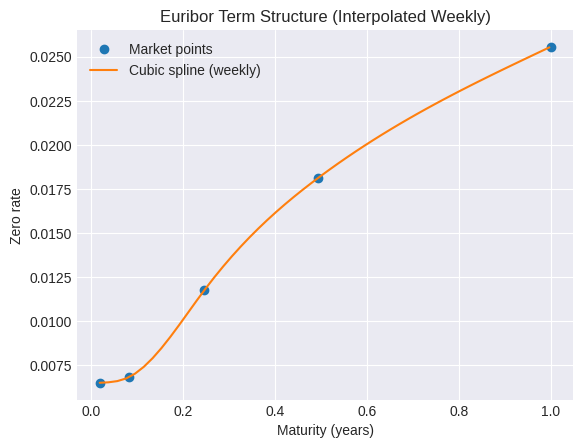

In [ ]:
# Weekly grid from 1 week to 1 year (avoid T=0 exactly)
T_weekly = np.arange(7/365, 365/365 + 1e-9, 7/365)

# Cubic spline interpolation of the given market zero rates
cs = CubicSpline(T, rates, bc_type="natural")
rates_weekly = cs(T_weekly)

# Plot
plt.figure()
plt.plot(T, rates, "o", label="Market points")
plt.plot(T_weekly, rates_weekly, "-", label="Cubic spline (weekly)")
plt.xlabel("Maturity (years)")
plt.ylabel("Zero rate")
plt.legend()
plt.title("Euribor Term Structure (Interpolated Weekly)")
plt.show()


In [ ]:
def cir_A_B(kappa, theta, sigma, T):
    """
    Returns A(T), B(T) arrays for CIR zero-coupon bond pricing.
    Works for numpy arrays T.
    """
    T = np.array(T, dtype=float)
    gamma = np.sqrt(kappa**2 + 2*sigma**2)

    exp_gT = np.exp(gamma * T)
    denom = (gamma + kappa) * (exp_gT - 1) + 2*gamma

    B = 2*(exp_gT - 1) / denom

    A = (2*gamma * np.exp((kappa + gamma)*T/2) / denom) ** (2*kappa*theta/(sigma**2))
    return A, B


def cir_zero_price(kappa, theta, sigma, r0, T):
    A, B = cir_A_B(kappa, theta, sigma, T)
    return A * np.exp(-B * r0)


def cir_zero_rate(kappa, theta, sigma, r0, T):
    P = cir_zero_price(kappa, theta, sigma, r0, T)
    return -np.log(P) / T


In [ ]:
r0 = rates[0]  # use 1W Euribor as proxy for instantaneous short rate

def objective(params):
    kappa, theta, sigma = params

    # enforce valid parameters; if invalid, punish heavily
    if kappa <= 0 or theta <= 0 or sigma <= 0:
        return 1e6

    # model rates at weekly maturities
    model_rates = cir_zero_rate(kappa, theta, sigma, r0, T_weekly)

    # squared error vs interpolated curve
    err = np.sum((model_rates - rates_weekly)**2)
    return err

# Initial guess (reasonable-ish)
x0 = np.array([1.0, 0.02, 0.05])  # kappa, theta, sigma

# Bounds to keep the optimizer stable
bounds = [(1e-4, 50.0), (1e-6, 0.5), (1e-6, 1.0)]

res = minimize(objective, x0, bounds=bounds, method="L-BFGS-B")
kappa_hat, theta_hat, sigma_hat = res.x

print("Calibration success:", res.success)
print("kappa =", kappa_hat)
print("theta =", theta_hat)
print("sigma =", sigma_hat)
print("objective =", res.fun)


Calibration success: True
kappa = 1.0004174351037798
theta = 0.0593064670792033
sigma = 0.0499935576972603
objective = 3.375978668482874e-05


In [ ]:
def simulate_cir_paths(kappa, theta, sigma, r0, n_paths=100000, n_steps=252, T_horizon=1.0, seed=42):
    rng = np.random.default_rng(seed)
    dt = T_horizon / n_steps

    r = np.empty((n_paths, n_steps + 1), dtype=float)
    r[:, 0] = r0

    for t in range(n_steps):
        z = rng.standard_normal(n_paths)
        # full truncation to prevent sqrt of negative
        rt = np.maximum(r[:, t], 0.0)
        r[:, t+1] = r[:, t] + kappa*(theta - rt)*dt + sigma*np.sqrt(rt*dt)*z
        r[:, t+1] = np.maximum(r[:, t+1], 0.0)

    return r

paths = simulate_cir_paths(kappa_hat, theta_hat, sigma_hat, r0)


In [ ]:
r_T = paths[:, -1]          # short rate at t=1 year
P_1y = cir_zero_price(kappa_hat, theta_hat, sigma_hat, r_T, 1.0)  # price from t to t+1
euribor_12m_in_1y = -np.log(P_1y) / 1.0

conf = 0.95
low_q = (1 - conf) / 2
high_q = 1 - low_q

low = np.quantile(euribor_12m_in_1y, low_q)
high = np.quantile(euribor_12m_in_1y, high_q)
mean = np.mean(euribor_12m_in_1y)

print(f"{int(conf*100)}% range: [{low:.4%}, {high:.4%}]")
print(f"Expected 12M Euribor in 1 year: {mean:.4%}")
print(f"Current 12M Euribor: {rates[-1]:.4%}")


95% range: [4.0377%, 5.4762%]
Expected 12M Euribor in 1 year: 4.7053%
Current 12M Euribor: 2.5560%


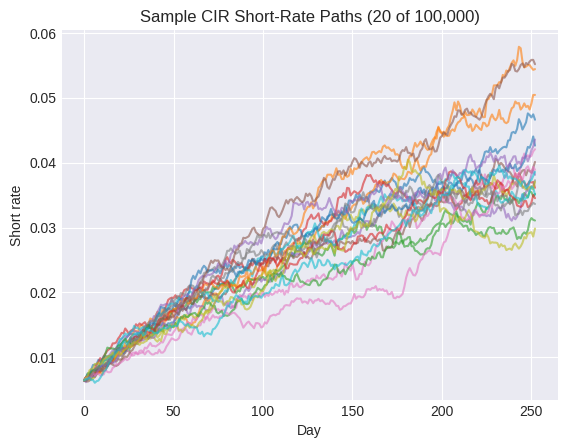

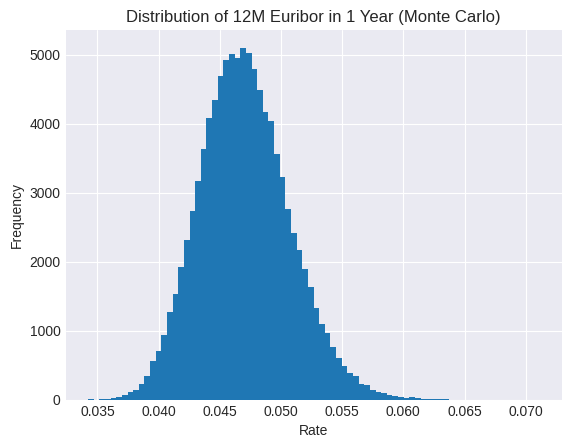

In [ ]:
# Example paths
plt.figure()
for i in range(20):
    plt.plot(paths[i, :], alpha=0.6)
plt.title("Sample CIR Short-Rate Paths (20 of 100,000)")
plt.xlabel("Day")
plt.ylabel("Short rate")
plt.show()

# Histogram of 12M Euribor in 1 year
plt.figure()
plt.hist(euribor_12m_in_1y, bins=80)
plt.title("Distribution of 12M Euribor in 1 Year (Monte Carlo)")
plt.xlabel("Rate")
plt.ylabel("Frequency")
plt.show()
